# Transcription Factor Project - Replogle et al. (2022) K562 Dataset Downstream Analysis
**Robin Anwyl, UCSD Subramaniam Lab**

**Goal:** Analyze the KOLF2.1J genome-wide Perturb-seq dataset from the Nourreddine et al. (2024) preprint to investigate the effects of transcription factor knockdowns (TF KDs). Compare to the Replogle et al. (2022) K562 genome-wide Perturb-seq dataset to explore cell-type-specific transcriptional regulatory networks in hiPSCs vs. chronic myeloid leukemia cells.

**Guiding Questions:** What do TF KD effects reveal about:
* the transcriptional regulatory network of hiPSCs and K562 cells?
* TF crosstalk and co-regulation?
* cell lineage?
* how TFs influence chromatin remodeling?

***

# Import statements

Using psp_env virtual env

In [1]:
import sys
import os
psp_root = "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/"
if psp_root not in sys.path:
    sys.path.insert(0, psp_root)

import psp

In [2]:
import anndata as ad
import numpy as np
import pandas as pd
import decoupler as dc
import gseapy as gp
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
from biothings_client import get_client

In [3]:
def validate_3_DGE_results_dfs(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Check that 3 DGE analysis results DFs have same rows and cols.
    """
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    DGE_results_1 = DGE_results_dfs[0].sort_index()
    DGE_results_2 = DGE_results_dfs[1].sort_index()
    DGE_results_3 = DGE_results_dfs[2].sort_index()
    if not (DGE_results_1.index.equals(DGE_results_2.index) and 
            DGE_results_2.index.equals(DGE_results_3.index)):
        raise ValueError("DGE results DataFrames must have same index (genes)")
    if not ((set(DGE_results_1.columns) == set(DGE_results_2.columns)) &
            (set(DGE_results_2.columns) == set(DGE_results_3.columns))):
        raise ValueError("DGE results DataFrames must have same columns (KDs)")
    # Return DFs with sorted index
    return [DGE_results_1, DGE_results_2, DGE_results_3]

def build_3_run_DEGs_dict(DGE_results_dfs: list[pd.DataFrame],
                          p_threshold: float,
                          p_threshold_type: str="pvalue",
                          target_type: str="gRNA",
                          targets: list[str] | set[str] | None = None,
                          lfc_threshold: float = 0,
                          lfc_col: str = "log2FoldChange",
                          validate: bool=True
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that are DEGs of that KD (pass significance 
    and LFC thresholds) in at least 2 DGE analysis runs.
    """
    # Check for valid significance threshold
    if p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("p_threshold_type must be 'pvalue' or 'padj'")
    # Check for valid target type
    if target_type not in ("gRNA", "gene_target"):
        raise ValueError("target_type must be 'gRNA' or 'gene_target'")
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Find genes that are DEGs of the same KD in at least 2 DGE runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if not targets:
        if target_type == "gRNA":
            targets = {"_".join(col.split("_")[:2]) for col in DGE_results_1.columns}
        else:
            targets = {col.split("_")[0] for col in DGE_results_1.columns}
    targets = sorted(list(targets))
    DEGs_dict = dict()
    for target in targets:
        target_p_col = f"{target}_{p_threshold_type}"
        target_lfc_col = f"{target}_{lfc_col}"
        DEGs_run1 = set(
            DGE_results_1.loc[(DGE_results_1[target_p_col] < p_threshold) & 
            (abs(DGE_results_1[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run2 = set(
            DGE_results_2.loc[(DGE_results_2[target_p_col] < p_threshold) & 
            (abs(DGE_results_2[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run3 = set(
            DGE_results_3.loc[(DGE_results_3[target_p_col] < p_threshold) & 
            (abs(DGE_results_3[target_lfc_col]) > lfc_threshold)].index)                                 
        DEGs_at_least_2 = ((DEGs_run1 & DEGs_run2) | (DEGs_run2 & DEGs_run3) |
                           (DEGs_run1 & DEGs_run3))
        DEGs_dict[target] = DEGs_at_least_2
    return DEGs_dict

def build_3_run_wald_dict(DGE_results_dfs: list[pd.DataFrame],
                          kds: list[str] | set[str] | None,
                          wald_col: str="stat",
                          wald_abs_threshold: float = 1,
                          validate: bool = True
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that have |Wald| > wald_abs_threshold 
    in at least 2 DGE analysis runs.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)

    # For each KD, find genes with |Wald| > 1 in at least 2 runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if not kds:
        kds = {col.split("_")[0] for col in DGE_results_1.columns}
    kds = sorted(list(kds))
    wald_dict = dict()
    for kd in kds:
        kd_wald_col = f"{kd}_{wald_col}"
        wald_genes_run1 = set(DGE_results_1.loc[
            abs(DGE_results_1[kd_wald_col]) > wald_abs_threshold].index)
        wald_genes_run2 = set(DGE_results_2.loc[
            abs(DGE_results_2[kd_wald_col]) > wald_abs_threshold].index)
        wald_genes_run3 = set(DGE_results_3.loc[
            abs(DGE_results_3[kd_wald_col]) > wald_abs_threshold].index)                                
        wald_genes_at_least_2 = ((wald_genes_run1 & wald_genes_run2) | 
                                 (wald_genes_run2 & wald_genes_run3) |
                                 (wald_genes_run1 & wald_genes_run3))
        wald_dict[kd] = wald_genes_at_least_2
    return wald_dict

def build_3_run_n_DEGs_df(DEGs_dict: dict[str, set[str]]
                          ) -> pd.DataFrame:
    """
    From a dict of DEGs for each KD, build a DataFrame reporting
    the number of DEGs per KD.
    """
    kds = list(DEGs_dict.keys())
    n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
    n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    n_DEGs_df = n_DEGs_df.sort_values(by="n_DEGs", ascending=False)
    return n_DEGs_df

def build_cluster_DEGs_dict(DEGs_dict: dict[str, set[str]],
                            cluster_df: pd.DataFrame
                            ) -> dict[int, set[str]]:
    """
    Build dict of DEGs per cluster.
    """
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_DEGs_dict = {
        cl: set().union(*[DEGs_dict[kd] for kd in cluster_kd_dict[cl]])
        for cl in cluster_kd_dict
    }
    return cluster_DEGs_dict

def plot_n_DEGs_per_cluster(cluster_DEGs_dict: dict[int, set[str]],
                            title: str, 
                            figsize: tuple[int, int] = (6,3), 
                            xlabel: str="Cluster", 
                            ymax: int | None = None,
                            color: str = "tab:blue"):
    """
    Given a dict of DEGs per cluster, plot number of DEGs per cluster.
    """
    clusters = sorted(list(cluster_DEGs_dict.keys()))
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in clusters]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=clusters, y=n_DEGs, ax=ax, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# DEGs per cluster")
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

# Read in data

In [4]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_NTC_norm_KDefficiency_Etest_gRNA_filtered.h5ad"
adata_k562 = psp.utils.read_anndata(filepath)
adata_k562

AnnData object with n_obs × n_vars = 244096 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'target_detected', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cel

In [5]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_k562_3 = pd.read_pickle(filepath3)
de_results_dfs_k562 = [de_results_k562_1, de_results_k562_2, de_results_k562_3]

In [6]:
kd_deg_dict_k562 = build_3_run_DEGs_dict(de_results_dfs_k562, p_threshold=0.005,
                                         p_threshold_type="pvalue", target_type="gene_target")

In [7]:
n_degs_df_k562 = build_3_run_n_DEGs_df(kd_deg_dict_k562)
n_degs_df_k562.head(25)

,n_DEGs
DNMT1,406
CXXC1,165
MAX,150
MYB,141
TFDP1,128
TBX1,120
ETV4,106
NKX6-1,103
SETDB1,94
ZBTB17,77


In [8]:
kd_subset = set(n_degs_df_k562[n_degs_df_k562['n_DEGs'] > 4].index)
print(f"{len(kd_subset)} out of {len(n_degs_df_k562)} TF KDs "
      f"have >4 DEGs consistent across least 2 DGE runs")

457 out of 916 TF KDs have >4 DEGs consistent across least 2 DGE runs


In [9]:
print(f"{len(n_degs_df_k562[n_degs_df_k562['n_DEGs'] >= 10])} out of {len(n_degs_df_k562)} TF KDs "
      f"have 10+ DEGs consistent across least 2 DGE runs")

197 out of 916 TF KDs have 10+ DEGs consistent across least 2 DGE runs


In [11]:
kd_wald_dict_k562 = build_3_run_wald_dict(de_results_dfs_k562,
                                          kds=kd_subset)

In [10]:
leiden_clusters_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_subset_leiden_clusters_spectral25-mde7-knn6-repulsive5_5-21-26.csv"
leiden_clusters_k562 = pd.read_csv(leiden_clusters_filepath, header=0, index_col=0)
leiden_clusters_k562.head(3)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,CENPB,DLX2,ARID5B,ARID2,ALX3,AEBP1,CDX2,CXXC4,AHCTF1,EVX2,...,AHRR,CREBZF,ESRRA,DR1,ERG,BATF,CHAMP1,FIGLA,AKAP8L,CREBL2
1,CTCFL,FOXM1,CPEB1,ATMIN,ARID3B,E2F3,CLOCK,FEV,BACH1,FIZ1,...,ELF4,E2F1,KMT2A,DRAP1,GMEB1,CEBPB,FOXK1,FOXL2,CARF,FLI1
2,FEZF1,FOXQ1,CXXC1,BPTF,FOXO1,GLI4,E4F1,FOS,GSC,FOXD4L1,...,FOSL1,FLYWCH1,LIN54,HOXD3,IRX1,FOXI3,FOXN2,FOXN1,E2F8,MTF1


In [12]:
cluster_deg_dict_k562 = build_cluster_DEGs_dict(kd_deg_dict_k562,
                                                leiden_clusters_k562)

In [14]:
sns.set_style("whitegrid")

2026-05-23 17:24:07 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-23 17:24:07 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


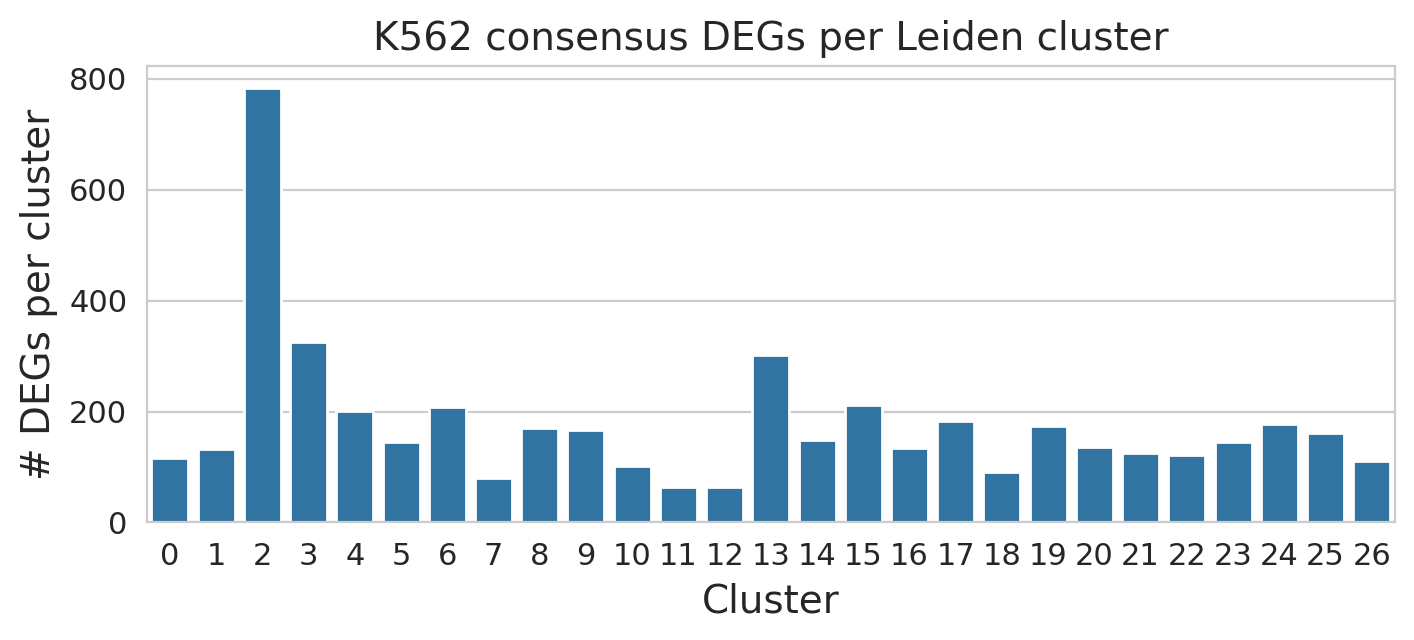

In [16]:
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_k562,
                            title="K562 consensus DEGs per Leiden cluster",
                            figsize=(8,3))

# Filter Entrez genes for Pathview (using DGE results)

In [ ]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_k562_3 = pd.read_pickle(filepath3)
de_results_dfs_k562 = [de_results_k562_1, de_results_k562_2, de_results_k562_3]

In [13]:
def filter_rename_entrez_genes(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Rename genes in DGE results DF by Entrez ID and remove genes
    without an Entrez ID.
    """
    # Check that DGE results DFs have same rows (genes)
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    if not ((set(DGE_results_dfs[0].index) == set(DGE_results_dfs[1].index)) &
            (set(DGE_results_dfs[1].index) == set(DGE_results_dfs[2].index))):
        raise ValueError("DGE results DataFrames must have same genes in index")

    # Query genes by symbol and Ensembl ID
    all_genes = DGE_results_dfs[0].index.tolist()
    mygene = get_client('gene')
    mg_results_df = mygene.querymany(all_genes, scopes="symbol,ensemblgene",
                                     field="entrezgene", species="human",
                                     entrezonly=True, as_dataframe=True)
    # Remove duplicates
    mg_results_df = mg_results_df.loc[~mg_results_df.index.duplicated(keep=False)]
    # First set of genes to rename
    found_mg_results_df = mg_results_df[mg_results_df["entrezgene"].notna()]
    gene_entrez_rename_dict1 = found_mg_results_df["entrezgene"].to_dict()

    # Query genes that were not found by alias
    genes_not_found = mg_results_df[mg_results_df["notfound"] == True].index.tolist()
    mg_alias_results_df = mygene.querymany(genes_not_found, scopes="alias", 
                                           field="entrezgene", species="human", 
                                           entrezonly=True, as_dataframe=True)
    # Remove duplicates
    mg_alias_results_df = \
        mg_alias_results_df.loc[~mg_alias_results_df.index.duplicated(keep=False)]
    # Second set of genes to rename
    found_mg_alias_results_df = mg_alias_results_df[mg_alias_results_df["entrezgene"].notna()]
    gene_entrez_rename_dict2 = found_mg_alias_results_df["entrezgene"].to_dict()

    # Rename genes
    gene_entrez_rename_dict = gene_entrez_rename_dict1 | gene_entrez_rename_dict2
    DGE_results_dfs_renamed = list()
    for DGE_df in DGE_results_dfs:
        DGE_df_renamed = DGE_df[DGE_df.index.isin(gene_entrez_rename_dict.keys())]
        DGE_df_renamed = DGE_df_renamed.rename(index=gene_entrez_rename_dict)
        DGE_results_dfs_renamed.append(DGE_df_renamed)
    return DGE_results_dfs_renamed

In [14]:
de_results_k562_1.shape

(8246, 5496)

In [15]:
de_results_entrez_k562 = \
    filter_rename_entrez_genes(de_results_dfs_k562)

2026-05-22 16:01:09 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-05-22 16:01:09 | [INFO] querying 1-1000 ...
2026-05-22 16:01:10 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:12 | [INFO] querying 1001-2000 ...
2026-05-22 16:01:13 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:14 | [INFO] querying 2001-3000 ...
2026-05-22 16:01:14 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:15 | [INFO] querying 3001-4000 ...
2026-05-22 16:01:16 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:17 | [INFO] querying 4001-5000 ...
2026-05-22 16:01:18 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:19 | [INFO] querying 5001-6000 ...
2026-05-22 16:01:20 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05

In [16]:
de_results_entrez_k562_1, de_results_entrez_k562_2, de_results_entrez_k562_3 = \
    de_results_entrez_k562[0], de_results_entrez_k562[1], de_results_entrez_k562[2]

In [17]:
de_results_entrez_k562_1.shape

(8122, 5496)

124 genes with no Entrez ID were removed

In [18]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26_entrez.pkl"
de_results_entrez_k562_1.to_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26_entrez.pkl"
de_results_entrez_k562_2.to_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26_entrez.pkl"
de_results_entrez_k562_3.to_pickle(filepath3)

In [19]:
kd_entrez_deg_dict_k562 = \
    build_3_run_DEGs_dict(de_results_entrez_k562, p_threshold=0.005,
                          p_threshold_type="pvalue", target_type="gene_target")

In [20]:
cluster_entrez_deg_dict = build_cluster_DEGs_dict(kd_entrez_deg_dict_k562,
                                                 leiden_clusters_k562)

In [22]:
sns.set_style("whitegrid")

2026-05-22 16:09:38 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-22 16:09:38 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


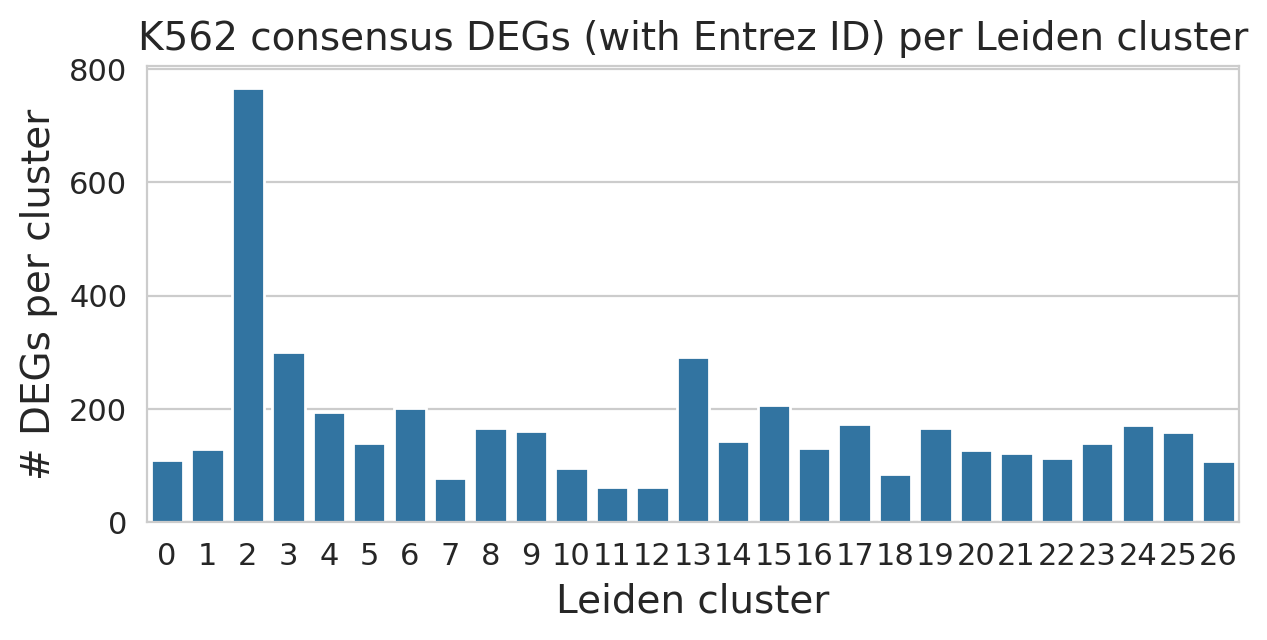

In [24]:
_ = plot_n_DEGs_per_cluster(cluster_entrez_deg_dict,
                            title="K562 consensus DEGs (with Entrez ID) per Leiden cluster",
                            figsize=(7,3), xlabel="Leiden cluster")

# Consensus LFC table for pathview/SBGNview

In [4]:
def build_consensus_lfc_dfs(
        DGE_results_dfs: list[pd.DataFrame],
        cluster_df: pd.DataFrame,
        p_threshold: float,
        p_threshold_type: str = "pvalue",
        lfc_col: str = "log2FoldChange",
        lfc_threshold: float = 0,
        ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build 2 DataFrames for pathway visualization, one 
    with consensus LFC values for each TF KD and one with 
    consensus LFC values for each cluster.

    If a gene is a DEG of a KD in at least 2 out of 3 DGE runs, it
    is a consensus DEG. For each KD, compute consensus LFC of each
    consensus DEG (take mean LFC of gene across any run where gene
    passes significance and LFC thresholds). Then for each cluster,
    for each gene, take mean of consensus LFCs across all cluster KDs.
    """
    # Check that DGE results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Build dict of KD: {consensus DEGs}
    DEGs_dict = build_3_run_DEGs_dict(DGE_results_dfs,
                                      p_threshold=p_threshold,
                                      p_threshold_type=p_threshold_type,
                                      target_type="gene_target",
                                      lfc_threshold=lfc_threshold,
                                      lfc_col=lfc_col,
                                      validate=False)
    
    # Get per-run LFC values
    kds = sorted(list(DEGs_dict.keys()))
    masked_run_lfc_dfs = list()
    for DGE_df in DGE_results_dfs:
        masked_lfc_cols = dict()
        for kd in kds:
            kd_p_col = DGE_df[f"{kd}_{p_threshold_type}"]
            kd_lfc_col = DGE_df[f"{kd}_{lfc_col}"].copy()
            # Get LFCs for genes that pass significance/LFC thresholds
            passes_run = (
                (kd_p_col < p_threshold) & (kd_lfc_col.abs() > lfc_threshold)
            ).fillna(False)
            # Set LFCs of genes that are not consensus DEGs to NaN
            in_consensus = kd_lfc_col.index.isin(DEGs_dict[kd])
            keep = passes_run.values & in_consensus
            kd_lfc_col[~keep] = np.nan
            # Add LFC col to dict
            masked_lfc_cols[kd] = kd_lfc_col
        # Add LFC cols for DGE run to list
        masked_run_lfc_df = pd.DataFrame(masked_lfc_cols, index=DGE_df.index)
        masked_run_lfc_dfs.append(masked_run_lfc_df)
    
    # Take mean LFCs across runs (skip NaNs)
    kd_consensus_lfc_df = pd.concat(masked_run_lfc_dfs).groupby(level=0).mean()

    # Build cluster LFC DF
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_lfc_cols = {}
    for cluster_num, cluster_kds in cluster_kd_dict.items():
        # Take mean LFC of each gene across cluster TF KDs
        cluster_lfc_cols[cluster_num] = \
            kd_consensus_lfc_df[cluster_kds].mean(axis=1).fillna(0)
    cluster_consensus_lfc_df = pd.DataFrame(cluster_lfc_cols, 
                                            index=kd_consensus_lfc_df.index)

    # Set NaN values to 0 in KD LFC DF
    kd_consensus_lfc_df = kd_consensus_lfc_df.fillna(0)
    
    return kd_consensus_lfc_df, cluster_consensus_lfc_df

In [5]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26_entrez.pkl"
de_results_entrez_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26_entrez.pkl"
de_results_entrez_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26_entrez.pkl"
de_results_entrez_k562_3 = pd.read_pickle(filepath3)
de_results_entrez_k562 = [de_results_entrez_k562_1, de_results_entrez_k562_2,
                          de_results_entrez_k562_3]

In [8]:
k562_kd_consensus_lfc_df, k562_cluster_consensus_lfc_df = \
    build_consensus_lfc_dfs(de_results_entrez_k562,
                            cluster_df=leiden_clusters_k562,
                            p_threshold=0.005, p_threshold_type="pvalue")

In [10]:
k562_kd_consensus_lfc_df.head()

,ADNP,ADNP2,AEBP1,AEBP2,AHCTF1,AHRR,AIRE,AKAP8,AKAP8L,AKNA,...,ZNF92,ZNF98,ZSCAN12,ZSCAN18,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN30,ZSCAN5A,ZSCAN9
gene_name,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
k562_kd_consensus_lfc_df[["DNMT1"]].head()

,DNMT1
gene_name,
1,0.000000
100,-0.697518
10001,0.000000
10005,0.000000
10006,0.000000


In [13]:
filepath = "/home/ranwyl/output_files_tf_project/K562_KD_lfcs_pathview_5-23-26.csv"
k562_kd_consensus_lfc_df.to_csv(filepath)

In [9]:
k562_cluster_consensus_lfc_df.head()

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
gene_name,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,-0.697518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10001,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10005,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10006,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
filepath = "/home/ranwyl/output_files_tf_project/K562_subset_leiden_cluster_lfcs_pathview_5-22-26.csv"
k562_cluster_consensus_lfc_df.to_csv(filepath)

# TF-target dict

In [ ]:
def build_tf_target_dict_signed(source_list: list[str] = ["CollecTRI", "DoRothEA", 
                                                          "TF_Perturbations_Followed_by_Expression",
                                                          "TF-LOF_Expression_from_GEO"], 
                                tfs_to_rename_dict: dict[str, list] | None = None, 
                                dorothea_levels=["A", "B", "C"]) -> dict[str, dict[str, set[str]]]:
    """
    Build dict {TF: {"UP": set of upreg genes, "DOWN": set of downreg genes}}
    using decoupler and gseapy.
    """
    all_dicts = list()

    if "CollecTRI" in source_list:
        collectri_df = dc.op.collectri(organism='human')
        collectri_dict = dict()
        for tf, gene, weight in collectri_df.iloc[:,:3].itertuples(index=False, name=None):
            if tf not in collectri_dict:
                collectri_dict[tf] = {"UP":set(), "DOWN":set()}
            if weight > 0: # TF is activator --> gene is downregulated
                collectri_dict[tf]["DOWN"].add(gene)
            else: # TF is repressor --> gene is upregulated
                collectri_dict[tf]["UP"].add(gene)
        all_dicts.append(collectri_dict)
    
    if "DoRothEA" in source_list:
        dorothea_df = dc.op.dorothea(organism='human', levels=dorothea_levels)
        dorothea_dict = dict()
        for tf, gene, weight in dorothea_df.iloc[:,:3].itertuples(index=False, name=None):
            if tf not in dorothea_dict:
                dorothea_dict[tf] = {"UP":set(), "DOWN":set()}
            if weight > 0:
                dorothea_dict[tf]["DOWN"].add(gene)
            else:
                dorothea_dict[tf]["UP"].add(gene)
        all_dicts.append(dorothea_dict)

    # Perturbation and LOF Enrichr libraries
    ko_lof_lib_list = list()
    if "TF_Perturbations_Followed_by_Expression" in source_list:
        pert_lib = gp.get_library(name="TF_Perturbations_Followed_by_Expression")
        ko_lof_lib_list.append(pert_lib)
    if "TF-LOF_Expression_from_GEO" in source_list:
        lof_lib = gp.get_library("TF-LOF_Expression_from_GEO")
        ko_lof_lib_list.append(lof_lib)
    if ko_lof_lib_list:
        ko_lof_dict = dict()
        for lib in ko_lof_lib_list:
            for tf_label, genes in lib.items():
                tf_label = tf_label.upper()
                if "HUMAN" in tf_label:
                    tf_label = tf_label.split(" ")
                    tf, reg = tf_label[0], tf_label[-1]
                    if tf not in ko_lof_dict:
                        ko_lof_dict[tf] = {"UP":set(), "DOWN":set()}
                    if reg == "UP":
                        ko_lof_dict[tf]["UP"].update(set(genes))
                    elif reg == "DOWN":
                        ko_lof_dict[tf]["DOWN"].update(set(genes))
        if tfs_to_rename_dict:
            for old_name, new_name in tfs_to_rename_dict.items():
                if new_name == "":
                    ko_lof_dict.pop(old_name)
                else:
                    ko_lof_dict[new_name] = ko_lof_dict.pop(old_name)
        all_dicts.append(ko_lof_dict)

    # Combine
    if len(all_dicts) == 1:
        return all_dicts[0]
    all_tfs = {tf for target_dict in all_dicts for tf in target_dict.keys()}
    all_tf_targets_dict = {tf: {"UP": set(), "DOWN": set()} for tf in all_tfs}
    for tf in all_tfs:
        genes_up = {g for target_dict in all_dicts if tf in target_dict for g in target_dict[tf]["UP"]}
        genes_down = {g for target_dict in all_dicts if tf in target_dict for g in target_dict[tf]["DOWN"]}
        all_tf_targets_dict[tf]["UP"].update(genes_up)
        all_tf_targets_dict[tf]["DOWN"].update(genes_down)
    return all_tf_targets_dict

In [ ]:
import pickle

In [ ]:
tfs_rename_dict = {"NCOA":"", "RENT1":"UPF1", "HIF2A":"EPAS1"} # old name : new name
tf_target_interactions_dict = build_tf_target_dict_signed(
    ["CollecTRI", "DoRothEA", "TF_Perturbations_Followed_by_Expression", "TF-LOF_Expression_from_GEO"], 
    tfs_to_rename_dict=tfs_rename_dict)

2026-03-05 14:31:34 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-05 14:31:54 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-05 14:32:16 | [INFO] 0017 gene_sets have been filtered out when max_size=2000 and min_size=0


Save as pickle

In [ ]:
tf_target_dict_filepath = "/home/ranwyl/reference_tf_project/tf_target_signed_interactions.pkl"
with open(tf_target_dict_filepath, 'wb') as f: # binary write mode
    pickle.dump(tf_target_interactions_dict, f)

In [ ]:
# TF target dict

import pickle

tf_target_dict_filepath = "/home/ranwyl/reference_tf_project/tf_target_signed_interactions.pkl"
with open(tf_target_dict_filepath, 'rb') as f: # binary read mode
    tf_target_interactions_dict = pickle.load(f)

# Cluster-level GSEA

In [11]:
def prerank_gsea_cluster_kds(
        cluster_label: int | str,
        DGE_results_dfs: list[pd.DataFrame], 
        gene_set_lib: str,
        cluster_df: pd.DataFrame | None = None,
        cluster_kds: list[str] | None = None,
        rank_by: str="stat",
        min_term_size: int=5, 
        max_term_size: int=1000, 
        permutation_num: int=1000, 
        n_cpus_per_job: int=4,
        n_jobs: int=1,
        random_seed: int=42,
        verbose: bool=False,
        kd_col: str="KD",
        cluster_col: str="Cluster",
        gene_set_col: str="Gene set"
    ) -> pd.DataFrame:
    """
    Run pre-ranked GSEA using the given Enrichr library on each 
    individual KD in a cluster. For each KD, compute mean Wald test
    statistic of each gene across 3 DGE analysis runs and rank genes by
    mean Wald. min_size and max_size control Enrichr term size.
    """
    # Get list of KDs in cluster
    if not cluster_kds:
        if not cluster_df:
            raise ValueError("Cluster DF or cluster KD list must be provided")
        if isinstance(cluster_df.columns[0], str):
            cluster_kds = list(cluster_df[str(cluster_label)][
                cluster_df[str(cluster_label)].notna()])
        else:
            cluster_kds = list(cluster_df[int(cluster_label)][
                cluster_df[int(cluster_label)].notna()])
    
    # Helper function to run GSEA on single KD
    def process_kd(kd):
        rank_col = f"{kd}_{rank_by}"
        rank_df_1 = pd.DataFrame(DGE_results_dfs[0][rank_col].values,
                                 index=DGE_results_dfs[0].index, 
                                 columns=[rank_by])
        rank_df_2 = pd.DataFrame(DGE_results_dfs[1][rank_col].values,
                                 index=DGE_results_dfs[1].index, 
                                 columns=[rank_by])
        rank_df_3 = pd.DataFrame(DGE_results_dfs[2][rank_col].values,
                                 index=DGE_results_dfs[2].index, 
                                 columns=[rank_by])
        rank_df = (rank_df_1 + rank_df_2 + rank_df_3) / 3
        rank_df.dropna(axis="index", inplace=True) # Drop NaN values
        rank_df.sort_values(by=rank_by, ascending=False, inplace=True)
        rank_df.index.name = "gene"
        # Run pre-ranked GSEA
        kd_prerank_result = \
            gp.prerank(rnk=rank_df,
                        gene_sets=gene_set_lib,
                        threads=n_cpus_per_job,
                        min_size=min_term_size,
                        max_size=max_term_size,
                        permutation_num=permutation_num,
                        outdir=None,
                        seed=random_seed,
                        verbose=verbose,
                        )
        return kd_prerank_result
    
    # Run GSEA on all KDs
    if n_jobs < 1:
        raise ValueError("Invalid value for n_jobs")
    if n_jobs == 1:
        kd_prerank_results_dict = dict()
        for kd in cluster_kds:
            kd_prerank_result = process_kd(kd)
            kd_prerank_results_dict[kd] = kd_prerank_result
    else: # Run in parallel
        with tqdm_joblib(desc="Running pre-ranked GSEA", 
                         total=len(cluster_kds)):
            kd_prerank_results = Parallel(n_jobs=n_jobs)(
                delayed(process_kd)(kd) for kd in cluster_kds)
        kd_prerank_results_dict = dict(zip(cluster_kds, kd_prerank_results))
    
    # Build results DF
    prerank_res_df_list = list()
    for kd in kd_prerank_results_dict:
        # Build results DF for KD
        kd_res_df = kd_prerank_results_dict[kd].res2d.copy()
        kd_res_df.insert(0, kd_col, [kd]*kd_res_df.shape[0])
        kd_res_df.drop(columns=["Name"], inplace=True)
        prerank_res_df_list.append(kd_res_df)
    # Build results DF for cluster
    cluster_prerank_res_df = pd.concat(prerank_res_df_list)
    cluster_prerank_res_df.insert(0, cluster_col, 
                                  [cluster_label]*cluster_prerank_res_df.shape[0])
    # Add gene set column
    cluster_prerank_res_df.insert(2, gene_set_col,
                                  [gene_set_lib]*cluster_prerank_res_df.shape[0])
    return cluster_prerank_res_df

def prerank_gsea_all_clusters(
        cluster_df: pd.DataFrame, 
        DGE_results_dfs: list[pd.DataFrame], 
        gene_set_lib: str,
        min_term_size: int=5, 
        max_term_size: int=1000, 
        permutation_num: int=1000, 
        n_cpus_per_cluster: int=4, 
        n_jobs_parallel: int=10,
        random_seed: int=42, 
        verbose: bool=False,
        rank_by: str = "stat",
        ) -> pd.DataFrame:
    """
    Run pre-ranked GSEA on all KDs using the given Enrichr library.
    For each KD, genes are ranked by mean Wald across 3 DGE analysis runs.
    Build a results DF where each term is labeled by KD and cluster.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Run GSEA
    cluster_kd_dict = {cl: list(cluster_df[cl][cluster_df[cl].notna()])
                       for cl in cluster_df.columns}   
    with tqdm_joblib(desc="Running pre-ranked GSEA", total=len(cluster_kd_dict)):
        cluster_prerank_results = Parallel(n_jobs=n_jobs_parallel)(
            delayed(prerank_gsea_cluster_kds)(
                    cluster_label=cluster,
                    cluster_kds=cluster_kd_dict[cluster], 
                    DGE_results_dfs=DGE_results_dfs, 
                    gene_set_lib=gene_set_lib, 
                    rank_by=rank_by,
                    min_term_size=min_term_size, 
                    max_term_size=max_term_size, 
                    permutation_num=permutation_num, 
                    n_cpus_per_job=n_cpus_per_cluster,
                    n_jobs=1,
                    random_seed=random_seed,
                    verbose=verbose)
                for cluster in cluster_kd_dict
            )
    prerank_results_df = pd.concat(cluster_prerank_results)
    return prerank_results_df

def build_enriched_gsea_terms_df(
        prerank_results_df: pd.DataFrame,
        DGE_results_dfs: list[pd.DataFrame],
        kd_col: str="KD",
        fdr_cutoff: float=0.05,
        fdr_col: str="FDR q-val",
        min_absolute_nes: None | float = None, 
        nes_col: str="NES",
        DGE_p_threshold: float = 0.05,
        DGE_p_threshold_type: str="pvalue",
        rank_by: str = "stat",
        rank_abs_threshold: int=1,
        leading_genes_col: str="Lead_genes",
        kd_DEG_dict: dict[str, set[str]] | None = None,
        kd_wald_dict: dict[str, set[str]] | None = None
    ) -> pd.DataFrame:
    """
    Subset the GSEA results DF to only enriched terms
    and add info on leading genes that are DEGs and
    that have |Wald| > 1 in at least 2 DGE analysis runs.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)

    # Subset to enriched terms (by FDR and NES)
    prerank_results_df = \
        prerank_results_df[prerank_results_df[fdr_col] < fdr_cutoff]
    if min_absolute_nes:
        prerank_results_df = \
            prerank_results_df[prerank_results_df[nes_col] >= min_absolute_nes]
    enriched_results_df = prerank_results_df.copy()
    
    # Add info on leading genes that pass DE significance threshold
    #   and have |Wald| > threshold in at least 2 DGE runs
    # Build dict {KD: {DEGs}}
    kds = set(prerank_results_df[kd_col].values)
    if not kd_DEG_dict:
        kd_DEG_dict = build_3_run_DEGs_dict(DGE_results_dfs, 
                                            p_threshold=DGE_p_threshold,
                                            p_threshold_type=DGE_p_threshold_type,
                                            validate=False)
    kd_DEG_dict = {k:v for k,v in kd_DEG_dict.items() if k in kds}
    # Build dict {KD: {genes with |Wald| > threshold}}
    if not kd_wald_dict:
        kd_wald_dict = build_3_run_wald_dict(DGE_results_dfs, 
                                            wald_col=rank_by,
                                            wald_abs_threshold=rank_abs_threshold,
                                            validate=False)
    kd_wald_dict = {k:v for k,v in kd_wald_dict.items() if k in kds}
    
    # Get leading gene DE + Wald info
    kds_arr = enriched_results_df[kd_col].to_numpy()
    lead_genes_arr = enriched_results_df[leading_genes_col].to_numpy()
    n_de_leading, de_leading_str, n_wald_leading, wald_leading_str = [], [], [], []
    for kd, lead_genes in zip(kds_arr, lead_genes_arr):
        leading_genes = set(s for s in lead_genes.split(";") if s)
        de_leading = leading_genes & kd_DEG_dict.get(kd, set())
        wald_leading = leading_genes & kd_wald_dict.get(kd, set())
        n_de_leading.append(len(de_leading))
        de_leading_str.append(";".join(sorted(de_leading)))
        n_wald_leading.append(len(wald_leading))
        wald_leading_str.append(";".join(sorted(wald_leading)))
    
    # Add leading gene DE + Wald info to DF
    enriched_results_df.insert(10, "# DE lead genes", n_de_leading)
    enriched_results_df.insert(11, f"# lead genes w/ |Wald| > {rank_abs_threshold}", 
                               n_wald_leading)
    enriched_results_df["DE_lead_genes"] = de_leading_str
    enriched_results_df["Wald_lead_genes"] = wald_leading_str
    return enriched_results_df

def build_cluster_shared_gsea_terms_df(
        enriched_results_df: pd.DataFrame,
        gene_set_lib: str,
        min_cluster_kds: int=3,
        max_term_size: int=200,
        kd_col: str="KD",
        cluster_col: str="Cluster", 
        nes_col: str="NES",
        leading_genes_col: str="Lead_genes",
        DE_leading_genes_col: str="DE_lead_genes",
        rank_leading_genes_col: str="Wald_lead_genes",
        gene_set_col: str="Gene set",
        rank_abs_threshold: float = 1
        ) -> pd.DataFrame:
    """
    Given a pre-ranked GSEA results DF with enriched terms and
    info on genes that pass DE and |Wald| thresholds, find terms 
    shared between multiple cluster KDs.
    """
    cluster_results_dfs, summary_entries = list(), list()
    # Get Enrichr library
    enrichr_lib = gp.get_library(gene_set_lib)
    # Loop through clusters
    clusters = sorted(enriched_results_df[cluster_col].unique().tolist(), key=int)
    for cl in clusters:
        # Get cluster DF
        cl_df = enriched_results_df[enriched_results_df[cluster_col] == cl]
        if cl_df.empty:
            continue
        # Group cluster DF by term for fast lookup
        term_groups = dict(list(cl_df.groupby("Term", sort=False)))
        # Subset to shared terms
        term_counts = cl_df["Term"].value_counts()
        cl_shared_terms = set(term_counts[term_counts >= min_cluster_kds].index)
        cl_shared_direction_terms = set()
        for term in cl_shared_terms:
            # Get only shared terms with max size
            term_size = len(enrichr_lib[term])
            if term_size > max_term_size:
                continue
            # Get only shared terms where all TF KDs have same NES sign
            cl_term_df = term_groups[term]
            nes_values = cl_term_df[nes_col].to_numpy()
            if not (np.all(nes_values > 0) or np.all(nes_values < 0)):
                continue
            cl_shared_direction_terms.add(term)
            # Build summary entry and add to list
            term_kds = sorted(cl_term_df[kd_col].unique().tolist())
            term_lead_genes = \
                {g for genes in cl_term_df[leading_genes_col].values 
                 for g in genes.split(";") if g}
            term_DE_lead_genes = \
                {g for genes in cl_term_df[DE_leading_genes_col].values 
                 for g in genes.split(";") if g}
            term_rank_lead_genes = \
                {g for genes in cl_term_df[rank_leading_genes_col].values 
                 for g in genes.split(";") if g}
            rank_lead_genes_col = f"Total leading genes w/ |Wald| > {rank_abs_threshold}"
            summary_entries.append(
                {"Cluster": cl, "Term": term, 
                 f"# {kd_col}s": len(term_kds),
                 f"{kd_col}s": ", ".join(term_kds),
                 "Mean NES": round(cl_term_df[nes_col].mean(), 2),
                 "Term size": term_size,
                 "Total leading genes": len(term_lead_genes),
                 "Total DE leading genes": len(term_DE_lead_genes),
                 rank_lead_genes_col: len(term_rank_lead_genes)}
                 )
        # Add cluster shared terms DF to list
        cl_df = cl_df[cl_df["Term"].isin(cl_shared_direction_terms)]
        cl_df.sort_values(by=["Term", kd_col], inplace=True)
        cluster_results_dfs.append(cl_df)
    
    # If no enriched terms
    if len(cluster_results_dfs) == 0:
        return pd.DataFrame(), pd.DataFrame()
    
    # Build shared terms DF
    if len(cluster_results_dfs) > 1:
        shared_terms_df = pd.concat(cluster_results_dfs)
        shared_terms_df.reset_index(drop=True, inplace=True)
    else:
        shared_terms_df = cluster_results_dfs[0]
    # Build summary DF
    summary_df = pd.DataFrame(summary_entries)
    summary_df.insert(1, gene_set_col, [gene_set_lib]*summary_df.shape[0])
    summary_df.sort_values(by=["Mean NES", f"# {kd_col}s"], 
                           ascending=False, inplace=True)
    summary_df.reset_index(drop=True, inplace=True)

    return shared_terms_df, summary_df

## Cluster 4 (TAL1, LYL1, KLF1)

Contains hematopoietic TF KDs TAL1 (50 DEGs), LYL1 (15), KLF1 (8), HOXA9 (6), RUNX3 (5)

In [13]:
cl4_tf_kds = list(leiden_clusters_k562["4"][leiden_clusters_k562["4"].notna()])
print(len(cl4_tf_kds))
print(", ".join(cl4_tf_kds))

23
ALX3, ARID3B, FOXO1, HOXA9, IKZF4, KLF1, KLF12, LYL1, NFYA, PAX6, POU2F2, RUNX3, TAL1, TCF24, ZNF8, ZNF75A, ZNF100, ZNF184, ZNF281, ZNF445, ZNF507, ZNF518B, ZNF652


In [16]:
n_degs_df_k562[n_degs_df_k562.index.isin(cl4_tf_kds)]

,n_DEGs
TAL1,50
FOXO1,50
ZNF281,39
ZNF518B,25
ZNF507,20
POU2F2,16
ZNF184,15
LYL1,15
TCF24,10
PAX6,9


### Hallmark

In [19]:
cl4_hallmark_results_full = prerank_gsea_cluster_kds(
    cluster_label=4,
    cluster_kds=cl4_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="MSigDB_Hallmark_2020",
    kd_col="TF KD",
    n_jobs=10,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/23 [00:00<?, ?it/s]

In [20]:
cl4_hallmark_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,4,ALX3,MSigDB_Hallmark_2020,Myc Targets V1,-0.386462,-1.939772,0.0,0.002652,0.004,98/195,31.46%,CDK2;HSPE1;CDK4;C1QBP;NPM1;RPS6;FAM120A;HSPD1;...
1,4,ALX3,MSigDB_Hallmark_2020,Myc Targets V2,-0.447438,-1.809275,0.0,0.009283,0.027,20/56,16.76%,SLC19A1;HSPE1;TMEM97;CDK4;NPM1;SORD;IPO4;HSPD1...
2,4,ALX3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.468341,1.761306,0.005405,0.058806,0.046,17/45,15.80%,JUN;TGFBR3;SAT1;LGALS1;WIPF1;TPM4;VEGFA;GADD45...


In [21]:
hallmark_filepath = "/home/ranwyl/results_tf_project/K562_cl4_gsea_hallmark_5-22-26.pkl"
cl4_hallmark_results_full.to_pickle(hallmark_filepath)

In [14]:
hallmark_filepath = "/home/ranwyl/results_tf_project/K562_cl4_gsea_hallmark_5-22-26.pkl"
cl4_hallmark_results_full = pd.read_pickle(hallmark_filepath)

In [15]:
cl4_hallmark_enriched = build_enriched_gsea_terms_df(
    cl4_hallmark_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1, 
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict = kd_wald_dict_k562
)

In [16]:
cl4_hallmark_shared_terms, cl4_hallmark_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl4_hallmark_enriched, gene_set_lib="MSigDB_Hallmark_2020",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl4_hallmark_shared_terms_degs_summary = cl4_hallmark_shared_terms_summary[
    cl4_hallmark_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 16:35:32 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 16:35:32 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file


In [24]:
print(f"{len(cl4_hallmark_shared_terms_summary)} Hallmark terms shared by 3+ cluster TF KDs")
print(f"{len(cl4_hallmark_shared_terms_degs_summary)} shared Hallmark terms with 3+ DE leading genes")

27 Hallmark terms shared by 3+ cluster TF KDs
11 shared Hallmark terms with 3+ DE leading genes


In [25]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl4_hallmark_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,4,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,18,"ARID3B, FOXO1, IKZF4, KLF1, KLF12, LYL1, PAX6, POU2F2, RUNX3, TAL1, TCF...",2.20,200,76,13,68
1,4,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,16,"ARID3B, FOXO1, HOXA9, IKZF4, KLF12, PAX6, TAL1, TCF24, ZNF184, ZNF281, ...",2.10,200,44,7,39
2,4,MSigDB_Hallmark_2020,Apoptosis,19,"ALX3, ARID3B, FOXO1, IKZF4, KLF1, KLF12, LYL1, NFYA, PAX6, POU2F2, TAL1...",1.91,161,80,8,64
3,4,MSigDB_Hallmark_2020,TGF-beta Signaling,5,"ARID3B, LYL1, TAL1, ZNF281, ZNF518B",1.90,54,31,2,23
4,4,MSigDB_Hallmark_2020,Inflammatory Response,14,"ARID3B, FOXO1, IKZF4, KLF12, LYL1, PAX6, POU2F2, TAL1, TCF24, ZNF281, Z...",1.84,200,50,6,37
5,4,MSigDB_Hallmark_2020,Interferon Alpha Response,6,"IKZF4, LYL1, POU2F2, TAL1, ZNF281, ZNF445",1.83,97,35,1,24
6,4,MSigDB_Hallmark_2020,Hedgehog Signaling,3,"ARID3B, FOXO1, NFYA",1.80,36,8,1,7
7,4,MSigDB_Hallmark_2020,p53 Pathway,16,"ARID3B, FOXO1, IKZF4, KLF1, KLF12, LYL1, PAX6, POU2F2, RUNX3, TAL1, TCF...",1.79,200,108,12,85
8,4,MSigDB_Hallmark_2020,IL-6/JAK/STAT3 Signaling,10,"FOXO1, KLF12, LYL1, PAX6, TAL1, TCF24, ZNF281, ZNF507, ZNF518B, ZNF8",1.79,87,31,3,22
9,4,MSigDB_Hallmark_2020,KRAS Signaling Up,5,"FOXO1, KLF12, LYL1, RUNX3, TAL1",1.78,200,46,5,29


In [26]:
up_terms = cl4_hallmark_shared_terms_summary[cl4_hallmark_shared_terms_summary['Mean NES'] > 0]
down_terms = cl4_hallmark_shared_terms_summary[cl4_hallmark_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared Hallmark terms: {', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared Hallmark terms: {', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared Hallmark terms: TNF-alpha Signaling via NF-kB, Epithelial Mesenchymal Transition, Apoptosis, TGF-beta Signaling, Inflammatory Response, Interferon Alpha Response, Hedgehog Signaling, p53 Pathway, IL-6/JAK/STAT3 Signaling, KRAS Signaling Up, Complement, Hypoxia, Interferon Gamma Response, heme Metabolism, Cholesterol Homeostasis, IL-2/STAT5 Signaling, KRAS Signaling Dn, Coagulation, Angiogenesis, Myogenesis, Apical Junction, Androgen Response
Negatively enriched shared Hallmark terms: Oxidative Phosphorylation, E2F Targets, G2-M Checkpoint, Myc Targets V2, Myc Targets V1


In [27]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 150):
    display(cl4_hallmark_shared_terms[
        cl4_hallmark_shared_terms['Term'] == 'Epithelial Mesenchymal Transition'])

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
1,4,ARID3B,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.624691,2.32122,0.0,0.0,0.0,19/45,1,16,10.30%,JUN;SAT1;AREG;LGALS1;IGFBP2;RHOB;IGFBP4;DAB2;VEGFA;TNFRSF12A;TIMP1;PLOD3;TPM4;P3H1;EMP3;PLAUR;TGFB1;MEST;FERMT2,JUN,AREG;DAB2;EMP3;IGFBP2;IGFBP4;JUN;LGALS1;P3H1;PLAUR;PLOD3;RHOB;SAT1;TIMP1;TNFRSF12A;TPM4;VEGFA
4,4,FOXO1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.572299,2.052725,0.0,0.000703,0.002,24/45,2,17,17.24%,LGALS1;JUN;TPM4;COPA;EMP3;IGFBP2;ENO2;FERMT2;SAT1;SLC6A8;DST;ITGAV;TPM1;FUCA1;TNFRSF12A;TIMP1;PLOD1;VEGFA;CALU;WIPF1;PLAUR;GADD45A;FLNA;MEST,JUN;LGALS1,COPA;DST;EMP3;ENO2;FERMT2;GADD45A;IGFBP2;ITGAV;JUN;LGALS1;PLAUR;SAT1;SLC6A8;TIMP1;TNFRSF12A;TPM1;TPM4
2,4,HOXA9,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.504221,1.865663,0.001808,0.013432,0.012,16/45,1,8,15.70%,AREG;JUN;EMP3;LGALS1;TIMP1;PLAUR;PMP22;RHOB;SERPINH1;ENO2;TNFRSF12A;TGFBR3;MEST;P3H1;MCM7;GADD45A,AREG,AREG;EMP3;JUN;LGALS1;PLAUR;PMP22;TGFBR3;TIMP1
9,4,IKZF4,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.436675,1.623103,0.008576,0.034962,0.174,14/45,0,8,15.60%,LGALS1;IGFBP2;ENO2;SAT1;JUN;DAB2;TIMP1;ITGAV;ITGB1;GADD45A;TNFRSF12A;WIPF1;PLOD2;PCOLCE2,,DAB2;ENO2;IGFBP2;ITGAV;JUN;LGALS1;SAT1;TIMP1
3,4,KLF12,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.589731,2.172716,0.0,0.0,0.0,14/45,0,11,9.50%,JUN;SAT1;LGALS1;RHOB;ENO2;PMP22;DAB2;TPM4;TIMP1;TGFBR3;EMP3;WIPF1;AREG;IGFBP2,,DAB2;ENO2;JUN;LGALS1;PMP22;RHOB;SAT1;TGFBR3;TIMP1;TPM4;WIPF1
1,4,PAX6,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.623409,2.320039,0.0,0.0,0.0,26/45,1,10,23.27%,JUN;LGALS1;AREG;IGFBP2;SAT1;DAB2;DST;COLGALT1;FERMT2;PLAUR;FUCA1;EMP3;RHOB;TPM1;ENO2;PLOD2;GADD45A;CALU;MSX1;TGFB1;COPA;SERPINH1;MEST;FLNA;WIPF1;V...,JUN,AREG;DST;EMP3;ENO2;FUCA1;IGFBP2;JUN;LGALS1;PLAUR;SAT1
4,4,TAL1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.593443,2.145399,0.0,0.000553,0.001,18/45,4,16,11.52%,SAT1;JUN;LGALS1;RHOB;AREG;TIMP1;FERMT2;TNFRSF12A;TPM4;CD59;DST;PLAUR;ENO2;TGFB1;SLC6A8;IGFBP2;COPA;CALU,JUN;LGALS1;RHOB;SAT1,AREG;CD59;DST;ENO2;FERMT2;IGFBP2;JUN;LGALS1;PLAUR;RHOB;SAT1;SLC6A8;TGFB1;TIMP1;TNFRSF12A;TPM4
3,4,TCF24,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.538959,1.97126,0.0,0.001739,0.003,18/45,2,13,13.57%,IGFBP2;JUN;LGALS1;P3H1;SAT1;EMP3;FERMT2;TPM4;RHOB;VEGFA;DST;FLNA;PMP22;COLGALT1;DAB2;SERPINH1;TNFRSF12A;IGFBP4,IGFBP2;JUN,DST;EMP3;FERMT2;FLNA;IGFBP2;JUN;LGALS1;P3H1;SAT1;SERPINH1;TNFRSF12A;TPM4;VEGFA
1,4,ZNF184,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.582725,2.196379,0.0,0.0,0.0,22/45,0,15,14.38%,AREG;DAB2;IGFBP2;ENO2;JUN;CD59;LGALS1;PMP22;WIPF1;FGF2;TIMP1;RHOB;SLC6A8;DST;PLOD2;TPM4;SAT1;TPM1;FLNA;TGFB1;MEST;VEGFA,,AREG;CD59;DAB2;DST;ENO2;FGF2;IGFBP2;JUN;LGALS1;PMP22;RHOB;SLC6A8;TIMP1;TPM4;WIPF1
4,4,ZNF281,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.634329,2.327566,0.0,0.0,0.0,18/45,5,16,8.97%,JUN;EMP3;SAT1;LGALS1;RHOB;IGFBP4;AREG;CD59;VIM;GADD45A;FLNA;PLAUR;TPM4;TNFRSF12A;TIMP1;TPM1;TGFB1;MEST,EMP3;JUN;LGALS1;RHOB;SAT1,AREG;CD59;EMP3;FLNA;GADD45A;IGFBP4;JUN;LGALS1;MEST;PLAUR;RHOB;SAT1;TIMP1;TNFRSF12A;TPM4;VIM


### GOBP

In [17]:
cl4_gobp_results_full = prerank_gsea_cluster_kds(
    cluster_label=4,
    cluster_kds=cl4_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="GO_Biological_Process_2025",
    kd_col="TF KD",
    max_term_size=500,
    n_jobs=8,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/23 [00:00<?, ?it/s]

In [18]:
cl4_gobp_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,4,ALX3,GO_Biological_Process_2025,Cytoplasmic Translation (GO:0002181),-0.609209,-2.744502,0.0,0.0,0.0,80/98,32.06%,RPS6;EEF1D;RPL22L1;RPL14;RACK1;RPL29;RPL3;RPL3...
1,4,ALX3,GO_Biological_Process_2025,Macromolecule Biosynthetic Process (GO:0009059),-0.498804,-2.409411,0.0,0.0,0.0,100/153,32.23%,RPS6;EEF1D;EIF5A2;MRPL32;MRPL10;EEF1B2;RPL14;R...
2,4,ALX3,GO_Biological_Process_2025,Translation (GO:0006412),-0.484069,-2.396522,0.0,0.0,0.0,128/204,32.23%,MRPS25;RPS6;EEF1D;MRPS26;EIF5A2;RPL22L1;MRPL32...


In [19]:
gobp_filepath = "/home/ranwyl/results_tf_project/K562_cl4_gsea_gobp_5-22-26.pkl"
cl4_gobp_results_full.to_pickle(gobp_filepath)

In [ ]:
gobp_filepath = "/home/ranwyl/results_tf_project/K562_cl4_gsea_gobp_5-22-26.pkl"
cl4_gobp_results_full = pd.read_pickle(gobp_filepath)

In [20]:
cl4_gobp_enriched = build_enriched_gsea_terms_df(
    cl4_gobp_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [ ]:
cl4_gobp_shared_terms, cl4_gobp_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl4_gobp_enriched, gene_set_lib="GO_Biological_Process_2025",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl4_gobp_shared_terms_degs_summary = cl4_gobp_shared_terms_summary[
    cl4_gobp_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 16:38:56 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 16:38:56 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-05-22 16:38:56 | [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


In [22]:
print(f"{len(cl4_gobp_shared_terms_summary)} GOBP terms shared by 3+ cluster TF KDs")
print(f"{len(cl4_gobp_shared_terms_degs_summary)} shared GOBP terms with 3+ DE leading genes")

12 GOBP terms shared by 3+ cluster TF KDs
2 shared GOBP terms with 3+ DE leading genes


In [24]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl4_gobp_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,4,GO_Biological_Process_2025,rRNA Metabolic Process (GO:0016072),3,"FOXO1, TAL1, ZNF184",-2.12,98,77,1,42
1,4,GO_Biological_Process_2025,Mitochondrial Translation (GO:0032543),3,"FOXO1, TAL1, ZNF518B",-2.17,94,74,0,34
2,4,GO_Biological_Process_2025,Ribosomal Large Subunit Biogenesis (GO:0042273),4,"FOXO1, TAL1, ZNF184, ZNF507",-2.21,47,41,1,25
3,4,GO_Biological_Process_2025,Oxidative Phosphorylation (GO:0006119),3,"IKZF4, TAL1, ZNF518B",-2.21,60,53,0,22
4,4,GO_Biological_Process_2025,Proton Motive Force-Driven ATP Synthesis (GO:0015986),3,"IKZF4, TAL1, ZNF518B",-2.23,59,52,0,23
5,4,GO_Biological_Process_2025,rRNA Processing (GO:0006364),4,"FOXO1, IKZF4, TAL1, ZNF184",-2.25,110,93,0,51
6,4,GO_Biological_Process_2025,Ribonucleoprotein Complex Biogenesis (GO:0022613),4,"FOXO1, TAL1, TCF24, ZNF184",-2.29,120,101,0,58
7,4,GO_Biological_Process_2025,Macromolecule Biosynthetic Process (GO:0009059),7,"ALX3, FOXO1, IKZF4, TAL1, TCF24, ZNF100, ZNF184",-2.31,189,147,1,77
8,4,GO_Biological_Process_2025,Hydrogen Peroxide Catabolic Process (GO:0042744),3,"TAL1, ZNF184, ZNF8",-2.39,20,10,4,10
9,4,GO_Biological_Process_2025,Hydrogen Peroxide Metabolic Process (GO:0042743),3,"TAL1, ZNF184, ZNF8",-2.43,28,12,4,11


In [25]:
up_terms = cl4_gobp_shared_terms_summary[cl4_gobp_shared_terms_summary['Mean NES'] > 0]
down_terms = cl4_gobp_shared_terms_summary[cl4_gobp_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared GOBP terms: {', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared GOBP terms: {', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared GOBP terms: 
Negatively enriched shared GOBP terms: rRNA Metabolic Process (GO:0016072), Mitochondrial Translation (GO:0032543), Ribosomal Large Subunit Biogenesis (GO:0042273), Oxidative Phosphorylation (GO:0006119), Proton Motive Force-Driven ATP Synthesis (GO:0015986), rRNA Processing (GO:0006364), Ribonucleoprotein Complex Biogenesis (GO:0022613), Macromolecule Biosynthetic Process (GO:0009059), Hydrogen Peroxide Catabolic Process (GO:0042744), Hydrogen Peroxide Metabolic Process (GO:0042743), Ribosome Biogenesis (GO:0042254), Cytoplasmic Translation (GO:0002181)


### Reactome

In [26]:
cl4_reactome_results_full = prerank_gsea_cluster_kds(
    cluster_label=4,
    cluster_kds=cl4_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="Reactome_Pathways_2024",
    kd_col="TF KD",
    n_jobs=8,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/23 [00:00<?, ?it/s]

In [27]:
cl4_reactome_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,4,ALX3,Reactome_Pathways_2024,Eukaryotic Translation Elongation,-0.636641,-2.793921,0.0,0.0,0.0,76/89,32.06%,RPL24;RPS6;EEF1D;RPL22L1;EEF1B2;RPL10;RPL14;RP...
1,4,ALX3,Reactome_Pathways_2024,Peptide Chain Elongation,-0.633555,-2.76181,0.0,0.0,0.0,75/86,33.13%,RPL24;RPS6;RPL22L1;RPL10;RPL14;RPL29;RPL3;RPL3...
2,4,ALX3,Reactome_Pathways_2024,Viral mRNA Translation,-0.629158,-2.757172,0.0,0.0,0.0,74/86,33.13%,RPL24;RPS6;RPL22L1;RPL10;RPL14;RPL29;RPL3;RPL3...


In [28]:
reac_filepath = "/home/ranwyl/results_tf_project/K562_cl4_gsea_reactome_5-22-26.pkl"
cl4_reactome_results_full.to_pickle(reac_filepath)

In [31]:
reac_filepath = "/home/ranwyl/results_tf_project/K562_cl4_gsea_reactome_5-22-26.pkl"
cl4_reactome_results_full = pd.read_pickle(reac_filepath)

In [32]:
cl4_reactome_enriched = build_enriched_gsea_terms_df(
    cl4_reactome_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [37]:
cl4_reactome_shared_terms, cl4_reactome_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl4_reactome_enriched, gene_set_lib="Reactome_Pathways_2024",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl4_reactome_shared_terms_degs_summary = cl4_reactome_shared_terms_summary[
    cl4_reactome_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 17:02:54 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 17:02:54 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.Reactome_Pathways_2024.gmt, use local file
2026-05-22 17:02:54 | [INFO] 0005 gene_sets have been filtered out when max_size=2000 and min_size=0


In [38]:
print(f"{len(cl4_reactome_shared_terms_summary)} Reactome terms shared by 3+ cluster TF KDs")
print(f"{len(cl4_reactome_shared_terms_degs_summary)} shared Reactome terms with 3+ DE leading genes")

44 Reactome terms shared by 3+ cluster TF KDs
1 shared Reactome terms with 3+ DE leading genes


In [32]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl4_reactome_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,4,Reactome_Pathways_2024,Response of EIF2AK1 (HRI) to Heme Deficiency,3,"PAX6, TAL1, TCF24",2.15,15,8,3,7
1,4,Reactome_Pathways_2024,Resolution of AP Sites via the Multiple-Nucleotide Patch Replacement Pa...,3,"ARID3B, RUNX3, ZNF281",-1.89,25,20,0,14
2,4,Reactome_Pathways_2024,Activation of the Pre-Replicative Complex,5,"ARID3B, PAX6, RUNX3, TAL1, ZNF281",-1.91,33,29,0,23
3,4,Reactome_Pathways_2024,Detoxification of Reactive Oxygen Species,5,"ARID3B, FOXO1, IKZF4, TAL1, ZNF100",-1.92,36,17,0,15
4,4,Reactome_Pathways_2024,Purine Ribonucleoside Monophosphate Biosynthesis,4,"FOXO1, TAL1, ZNF184, ZNF281",-1.92,11,10,0,7
5,4,Reactome_Pathways_2024,SARS-CoV-1-host Interactions,3,"ALX3, TAL1, TCF24",-1.94,112,64,0,21
6,4,Reactome_Pathways_2024,Nucleotide Biosynthesis,4,"FOXO1, TAL1, ZNF184, ZNF281",-1.98,14,13,0,10
7,4,Reactome_Pathways_2024,Cristae Formation,3,"FOXO1, IKZF4, TAL1",-1.99,33,29,0,14
8,4,Reactome_Pathways_2024,Formation of ATP by Chemiosmotic Coupling,3,"ALX3, TAL1, ZNF518B",-2.00,20,18,0,9
9,4,Reactome_Pathways_2024,tRNA Processing in the Mitochondrion,3,"FOXO1, IKZF4, TAL1",-2.04,42,17,0,10


In [33]:
up_terms = cl4_reactome_shared_terms_summary[cl4_reactome_shared_terms_summary['Mean NES'] > 0]
down_terms = cl4_reactome_shared_terms_summary[cl4_reactome_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared Reactome terms: "
      f"{', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared Reactome terms: "
      f"{', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared Reactome terms: Response of EIF2AK1 (HRI) to Heme Deficiency
Negatively enriched shared Reactome terms: Resolution of AP Sites via the Multiple-Nucleotide Patch Replacement Pathway, Activation of the Pre-Replicative Complex, Detoxification of Reactive Oxygen Species, Purine Ribonucleoside Monophosphate Biosynthesis, SARS-CoV-1-host Interactions, Nucleotide Biosynthesis, Cristae Formation, Formation of ATP by Chemiosmotic Coupling, tRNA Processing in the Mitochondrion, Cellular Response to Starvation, Mitochondrial Translation Initiation, DNA Strand Elongation, Mitochondrial Translation Termination, Mitochondrial Translation, Mitochondrial Translation Elongation, mRNA Activation Upon Binding of the Cap-Binding Complex and eIFs, and Subsequent Binding to 43S, Response of EIF2AK4 (GCN2) to Amino Acid Deficiency, Translation Initiation Complex Formation, Formation of the Ternary Complex, and Subsequently, the 43S Complex, Ribosomal Scanning and Start Codon Recogn

### KEGG

In [34]:
cl4_kegg_results_full = prerank_gsea_cluster_kds(
    cluster_label=4,
    cluster_kds=cl4_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="KEGG_2026",
    kd_col="TF KD",
    n_jobs=8,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/23 [00:00<?, ?it/s]

In [35]:
cl4_kegg_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,4,ALX3,KEGG_2026,RIBOSOME,-0.567846,-2.697823,0.0,0.0,0.0,104/149,32.23%,MRPS25;RPS6;MRPS26;RPL22L1;MRPL32;MRPL10;RPL14...
1,4,ALX3,KEGG_2026,PLATELET ACTIVATION,0.49318,1.946084,0.0,0.071099,0.057,26/60,21.37%,PIK3CG;MAPK14;GNAQ;PIK3R2;FYN;TLN1;PLCB4;PPP1C...
2,4,ALX3,KEGG_2026,VITAMIN DIGESTION AND ABSORPTION,-0.85947,-1.915536,0.001988,0.040535,0.094,4/6,9.73%,SLC19A1;ABCC1;SLC5A6;SCARB1


In [36]:
kegg_filepath = "/home/ranwyl/results_tf_project/K562_cl4_gsea_kegg_5-22-26.pkl"
cl4_kegg_results_full.to_pickle(kegg_filepath)

In [ ]:
kegg_filepath = "/home/ranwyl/results_tf_project/K562_cl4_gsea_kegg_5-22-26.pkl"
cl4_kegg_results_full = pd.read_pickle(kegg_filepath)

In [37]:
cl4_kegg_enriched = build_enriched_gsea_terms_df(
    cl4_kegg_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [38]:
cl4_kegg_shared_terms, cl4_kegg_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl4_kegg_enriched, gene_set_lib="KEGG_2026",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl4_kegg_shared_terms_degs_summary = cl4_kegg_shared_terms_summary[
    cl4_kegg_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 16:42:56 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 16:42:56 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.KEGG_2026.gmt, use local file


In [39]:
print(f"{len(cl4_kegg_shared_terms_summary)} KEGG terms shared by 3+ cluster TF KDs")
print(f"{len(cl4_kegg_shared_terms_degs_summary)} shared KEGG terms with 3+ DE leading genes")

10 KEGG terms shared by 3+ cluster TF KDs
3 shared KEGG terms with 3+ DE leading genes


In [40]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl4_kegg_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,4,KEGG_2026,EPITHELIAL CELL SIGNALING IN HELICOBACTER PYLORI INFECTION,3,"FOXO1, ZNF507, ZNF518B",2.01,70,34,1,22
1,4,KEGG_2026,PLATELET ACTIVATION,5,"FOXO1, LYL1, NFYA, TAL1, ZNF518B",2.00,125,52,4,36
2,4,KEGG_2026,OSTEOCLAST DIFFERENTIATION,5,"FOXO1, LYL1, TAL1, ZNF281, ZNF518B",1.99,134,55,6,35
3,4,KEGG_2026,RHEUMATOID ARTHRITIS,4,"FOXO1, LYL1, ZNF507, ZNF518B",1.96,92,25,1,16
4,4,KEGG_2026,NATURAL KILLER CELL MEDIATED CYTOTOXICITY,4,"FOXO1, TAL1, ZNF281, ZNF8",1.95,131,44,4,33
5,4,KEGG_2026,PHAGOSOME,3,"FOXO1, LYL1, ZNF507",1.94,151,47,1,32
6,4,KEGG_2026,DILATED CARDIOMYOPATHY,3,"NFYA, TAL1, ZNF8",1.92,103,16,0,12
7,4,KEGG_2026,DRUG METABOLISM - OTHER ENZYMES,3,"TAL1, TCF24, ZNF507",-1.92,81,26,0,12
8,4,KEGG_2026,RIBOSOME BIOGENESIS IN EUKARYOTES,3,"ARID3B, FOXO1, TAL1",-2.07,76,56,0,28
9,4,KEGG_2026,RIBOSOME,10,"ALX3, ARID3B, FOXO1, IKZF4, PAX6, TAL1, TCF24, ZNF100, ZNF184, ZNF75A",-2.40,160,149,0,79


In [41]:
up_terms = cl4_kegg_shared_terms_summary[cl4_kegg_shared_terms_summary['Mean NES'] > 0]
down_terms = cl4_kegg_shared_terms_summary[cl4_kegg_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared KEGG terms: "
      f"{', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared KEGG terms: "
      f"{', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared KEGG terms: EPITHELIAL CELL SIGNALING IN HELICOBACTER PYLORI INFECTION, PLATELET ACTIVATION, OSTEOCLAST DIFFERENTIATION, RHEUMATOID ARTHRITIS, NATURAL KILLER CELL MEDIATED CYTOTOXICITY, PHAGOSOME, DILATED CARDIOMYOPATHY
Negatively enriched shared KEGG terms: DRUG METABOLISM - OTHER ENZYMES, RIBOSOME BIOGENESIS IN EUKARYOTES, RIBOSOME


### All gene set libraries

In [44]:
cl4_shared_terms = pd.concat([cl4_hallmark_shared_terms, cl4_gobp_shared_terms, 
                               cl4_reactome_shared_terms, cl4_kegg_shared_terms])
cl4_shared_terms.reset_index(drop=True, inplace=True)
cl4_shared_terms.insert(0, "Cell line", ["K562"]*cl4_shared_terms.shape[0])
print(cl4_shared_terms.shape)
cl4_shared_terms.head(3)

(631, 17)


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,4,LYL1,MSigDB_Hallmark_2020,Androgen Response,0.393856,1.556154,0.019678,0.0275,0.294,24/64,0,10,23.48%,ARID5B;SPCS3;SGK1;SAT1;INSIG1;ELL2;SELENOP;SRF...,,ARID5B;B2M;ELL2;HMGCS1;IDI1;INSIG1;SAT1;SELENO...
1,K562,4,ZNF518B,MSigDB_Hallmark_2020,Androgen Response,0.3921,1.550582,0.008818,0.03196,0.326,20/64,0,14,16.61%,TSC22D1;TNFAIP8;SAT1;MYL12A;ARID5B;ELL2;INSIG1...,,ARID5B;DNAJB9;ELL2;ELOVL5;GNAI3;INSIG1;MYL12A;...
2,K562,4,ZNF652,MSigDB_Hallmark_2020,Androgen Response,0.397926,1.616914,0.00369,0.048435,0.179,16/64,1,8,13.58%,TSC22D1;STK39;CDC14B;FADS1;ELOVL5;SAT1;IDI1;IT...,TSC22D1,CDC14B;ELOVL5;FADS1;IDI1;SAT1;SELENOP;STK39;TS...


In [45]:
filepath = "/home/ranwyl/output_files_tf_project/K562_leiden_cl4_gsea_shared_terms.csv"
cl4_shared_terms.to_csv(filepath)

## Cluster 2 (DNMT1, CXXC1, NKX6-1, ZBTB17, TBP, ZNF84)

Contains epigenetic regulator TF KDs DNMT1 (406 DEGs), CXXC1 (165), NKX6-1 (103), ZBTB17 (77), TBP (68), ZNF84 (61)

In [13]:
cl2_tf_kds = list(leiden_clusters_k562["2"][leiden_clusters_k562["2"].notna()])
print(len(cl2_tf_kds))
print(", ".join(cl2_tf_kds))

25
ARID5B, CPEB1, CXXC1, DNMT1, HHEX, HLF, HOXA3, KLF16, MEIS3, MXD4, MYSM1, MZF1, NKX6-1, RFX4, RLF, SOX11, TBP, YBX3, ZBTB17, ZBTB24, ZFP57, ZIK1, ZNF84, ZNF236, ZNF396


In [14]:
n_degs_df_k562[n_degs_df_k562.index.isin(cl2_tf_kds)]

,n_DEGs
DNMT1,406
CXXC1,165
NKX6-1,103
ZBTB17,77
TBP,68
ZNF84,61
CPEB1,41
YBX3,38
MEIS3,37
ZNF236,34


### Hallmark

In [15]:
cl2_hallmark_results_full = prerank_gsea_cluster_kds(
    cluster_label=2,
    cluster_kds=cl2_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="MSigDB_Hallmark_2020",
    kd_col="TF KD",
    n_jobs=10,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/25 [00:00<?, ?it/s]

In [16]:
cl2_hallmark_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,2,ARID5B,MSigDB_Hallmark_2020,Myc Targets V1,-0.541044,-2.684652,0.0,0.0,0.0,88/195,19.40%,RPL6;RPS3;RPS2;RPS10;PHB2;RPS6;RPL18;NPM1;ODC1...
1,2,ARID5B,MSigDB_Hallmark_2020,heme Metabolism,0.5756,2.632321,0.0,0.0,0.0,46/133,9.68%,GYPB;HBZ;ALAS2;BTG2;GYPA;GYPE;NCOA4;MYL4;CCND3...
2,2,ARID5B,MSigDB_Hallmark_2020,Myc Targets V2,-0.523685,-2.104512,0.0,0.0,0.0,38/56,28.96%,NPM1;HSPD1;NOP2;DDX18;SRM;IPO4;SUPV3L1;WDR43;T...


In [17]:
hallmark_filepath = "/home/ranwyl/results_tf_project/K562_cl2_gsea_hallmark_5-22-26.pkl"
cl2_hallmark_results_full.to_pickle(hallmark_filepath)

In [ ]:
hallmark_filepath = "/home/ranwyl/results_tf_project/K562_cl2_gsea_hallmark_5-22-26.pkl"
cl2_hallmark_results_full = pd.read_pickle(hallmark_filepath)

In [18]:
cl2_hallmark_enriched = build_enriched_gsea_terms_df(
    cl2_hallmark_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1, 
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict = kd_wald_dict_k562
)

In [20]:
cl2_hallmark_shared_terms, cl2_hallmark_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl2_hallmark_enriched, gene_set_lib="MSigDB_Hallmark_2020",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl2_hallmark_shared_terms_degs_summary = cl2_hallmark_shared_terms_summary[
    cl2_hallmark_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 16:58:31 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 16:58:31 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file


In [21]:
print(f"{len(cl2_hallmark_shared_terms_summary)} Hallmark terms shared by 3+ cluster TF KDs")
print(f"{len(cl2_hallmark_shared_terms_degs_summary)} shared Hallmark terms with 3+ DE leading genes")

25 Hallmark terms shared by 3+ cluster TF KDs
15 shared Hallmark terms with 3+ DE leading genes


In [22]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl2_hallmark_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,2,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,18,"ARID5B, CPEB1, HHEX, HLF, HOXA3, KLF16, MEIS3, MXD4, MZF1, RFX4, RLF, S...",2.06,200,76,9,67
1,2,MSigDB_Hallmark_2020,heme Metabolism,17,"ARID5B, CPEB1, CXXC1, DNMT1, HHEX, HLF, HOXA3, KLF16, MZF1, RLF, SOX11,...",1.92,200,130,16,115
2,2,MSigDB_Hallmark_2020,Apoptosis,15,"ARID5B, DNMT1, HHEX, HLF, HOXA3, KLF16, MEIS3, MZF1, RFX4, RLF, SOX11, ...",1.88,161,83,11,72
3,2,MSigDB_Hallmark_2020,KRAS Signaling Dn,4,"ARID5B, KLF16, ZFP57, ZNF84",1.85,200,23,3,17
4,2,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,13,"CXXC1, HHEX, HLF, HOXA3, KLF16, MEIS3, MZF1, RFX4, RLF, YBX3, ZBTB17, Z...",1.84,200,45,6,41
5,2,MSigDB_Hallmark_2020,Coagulation,4,"CXXC1, MZF1, SOX11, ZNF84",1.82,138,30,2,19
6,2,MSigDB_Hallmark_2020,Complement,3,"HHEX, SOX11, ZBTB17",1.82,200,57,2,33
7,2,MSigDB_Hallmark_2020,IL-6/JAK/STAT3 Signaling,6,"CXXC1, HHEX, MZF1, YBX3, ZBTB24, ZIK1",1.80,87,26,2,19
8,2,MSigDB_Hallmark_2020,Inflammatory Response,5,"KLF16, YBX3, ZBTB17, ZBTB24, ZNF84",1.77,200,43,2,33
9,2,MSigDB_Hallmark_2020,Hypoxia,8,"ARID5B, HHEX, HLF, HOXA3, RLF, YBX3, ZBTB17, ZBTB24",1.75,200,62,5,50


In [23]:
up_terms = cl2_hallmark_shared_terms_summary[cl2_hallmark_shared_terms_summary['Mean NES'] > 0]
down_terms = cl2_hallmark_shared_terms_summary[cl2_hallmark_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared Hallmark terms: {', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared Hallmark terms: {', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared Hallmark terms: TNF-alpha Signaling via NF-kB, heme Metabolism, Apoptosis, KRAS Signaling Dn, Epithelial Mesenchymal Transition, Coagulation, Complement, IL-6/JAK/STAT3 Signaling, Inflammatory Response, Hypoxia, p53 Pathway, KRAS Signaling Up, UV Response Dn, Interferon Gamma Response, Estrogen Response Early, Angiogenesis, Apical Surface, Androgen Response, TGF-beta Signaling
Negatively enriched shared Hallmark terms: Allograft Rejection, Unfolded Protein Response, Oxidative Phosphorylation, E2F Targets, Myc Targets V2, Myc Targets V1


In [24]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 150):
    display(cl2_hallmark_shared_terms[
        cl2_hallmark_shared_terms['Term'] == 'Epithelial Mesenchymal Transition'])

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
8,2,CXXC1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.466917,1.697661,0.0,0.023853,0.083,16/45,3,16,12.82%,TIMP1;SAT1;CD59;FUCA1;LGALS1;DST;CALU;SERPINH1;PPIB;PLOD2;DAB2;IGFBP4;TGFB1;AREG;JUN;P3H1,CD59;SAT1;TIMP1,AREG;CALU;CD59;DAB2;DST;FUCA1;IGFBP4;JUN;LGALS1;P3H1;PLOD2;PPIB;SAT1;SERPINH1;TGFB1;TIMP1
7,2,HHEX,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.5206,1.876387,0.0,0.002742,0.012,25/45,1,18,18.43%,JUN;LGALS1;TIMP1;TPM4;TPM1;PLOD3;GADD45A;VEGFA;SAT1;DST;ITGAV;IGFBP4;SERPINH1;FLNA;CD59;FGF2;P3H1;TNFRSF12A;AREG;MCM7;TGFB1;CALU;COPA;MEST;IGFBP2,JUN,AREG;CD59;DST;FGF2;FLNA;GADD45A;IGFBP4;ITGAV;JUN;LGALS1;PLOD3;SAT1;SERPINH1;TIMP1;TNFRSF12A;TPM1;TPM4;VEGFA
6,2,HLF,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.522095,1.956963,0.0,0.001295,0.004,18/45,1,8,18.03%,JUN;LGALS1;FERMT2;PLAUR;FLNA;PMP22;GADD45A;P3H1;CD59;TGFB1;TNFRSF12A;ITGB1;TPM4;CAPG;RHOB;WIPF1;EMP3;MEST,JUN,FERMT2;FLNA;GADD45A;JUN;LGALS1;P3H1;PLAUR;TGFB1
5,2,HOXA3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.484597,1.773894,0.0,0.012994,0.032,21/45,1,9,26.52%,JUN;LGALS1;SAT1;AREG;TPM1;TGFBR3;MEST;RHOB;ENO2;P3H1;FGF2;GADD45A;CALU;PLAUR;PLOD2;FERMT2;CD59;TNFRSF12A;PMP22;COPA;DST,JUN,AREG;ENO2;JUN;LGALS1;MEST;RHOB;SAT1;TGFBR3;TPM1
16,2,KLF16,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.397681,1.510417,0.021429,0.047562,0.414,15/45,0,10,14.83%,MEST;ITGAV;JUN;GADD45A;FGF2;IGFBP2;TNFRSF12A;CD59;SAT1;TIMP1;TPM4;ITGB1;TGFB1;VIM;LGALS1,,CD59;FGF2;GADD45A;IGFBP2;ITGAV;JUN;MEST;TIMP1;TNFRSF12A;TPM4
4,2,MEIS3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.529751,1.990143,0.0,0.001211,0.003,13/45,1,13,7.98%,JUN;LGALS1;SAT1;VIM;AREG;TIMP1;DST;DAB2;TGFB1;ITGAV;TPM4;COLGALT1;COPA,JUN,AREG;COLGALT1;COPA;DAB2;DST;ITGAV;JUN;LGALS1;SAT1;TGFB1;TIMP1;TPM4;VIM
3,2,MZF1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.547958,2.030066,0.0,0.00118,0.002,18/45,2,14,12.16%,JUN;LGALS1;TNFRSF12A;FLNA;SAT1;FUCA1;RHOB;VEGFA;FGF2;ENO2;COLGALT1;TPM4;VIM;COPA;TGFB1;PLAUR;TIMP1;IGFBP4,JUN;LGALS1,COLGALT1;ENO2;FGF2;FLNA;FUCA1;JUN;LGALS1;RHOB;SAT1;TGFB1;TNFRSF12A;TPM4;VEGFA;VIM
6,2,RFX4,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.470012,1.754678,0.001805,0.011156,0.048,15/45,1,7,16.83%,JUN;AREG;SAT1;WIPF1;ITGB1;RHOB;PMP22;PLOD1;VEGFA;VIM;FUCA1;SLC6A8;TNFRSF12A;DAB2;P3H1,JUN,AREG;FUCA1;JUN;PMP22;RHOB;SAT1;WIPF1
6,2,RLF,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.447567,1.698411,0.003788,0.023898,0.099,15/45,2,8,10.48%,SAT1;JUN;AREG;GADD45A;PMP22;PLOD2;RHOB;LGALS1;IGFBP2;FGF2;DST;CD59;MSX1;MCM7;TIMP1,JUN;SAT1,AREG;DST;GADD45A;JUN;MCM7;PLOD2;PMP22;SAT1
3,2,YBX3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.525141,1.920817,0.002028,0.000895,0.002,14/45,1,13,8.15%,JUN;TNFRSF12A;SAT1;LGALS1;TIMP1;DST;EMP3;VIM;TGFB1;PMP22;SLC6A8;P3H1;VEGFA;CD59,JUN,DST;EMP3;JUN;LGALS1;P3H1;PMP22;SAT1;SLC6A8;TGFB1;TIMP1;TNFRSF12A;VEGFA;VIM


### GOBP

In [25]:
cl2_gobp_results_full = prerank_gsea_cluster_kds(
    cluster_label=2,
    cluster_kds=cl2_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="GO_Biological_Process_2025",
    kd_col="TF KD",
    max_term_size=500,
    n_jobs=9,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/25 [00:00<?, ?it/s]

In [26]:
cl2_gobp_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,2,ARID5B,GO_Biological_Process_2025,Cytoplasmic Translation (GO:0002181),-0.773787,-3.46839,0.0,0.0,0.0,54/98,8.11%,RPL36;RPS18;RPL6;RPS3;RPL12;RPS2;RPS10;RPL7;RP...
1,2,ARID5B,GO_Biological_Process_2025,Macromolecule Biosynthetic Process (GO:0009059),-0.660289,-3.138409,0.0,0.0,0.0,79/153,14.21%,RPL36;RPS18;RPL6;RPS3;RPL12;RPS2;RPS10;EEF1G;R...
2,2,ARID5B,GO_Biological_Process_2025,Translation (GO:0006412),-0.615272,-3.02505,0.0,0.0,0.0,100/204,16.32%,RPL36;RPS18;RPL6;RPS3;RPL12;RPS2;RPS10;EEF1G;R...


In [27]:
gobp_filepath = "/home/ranwyl/results_tf_project/K562_cl2_gsea_gobp_5-22-26.pkl"
cl2_gobp_results_full.to_pickle(gobp_filepath)

In [ ]:
gobp_filepath = "/home/ranwyl/results_tf_project/K562_cl2_gsea_gobp_5-22-26.pkl"
cl2_gobp_results_full = pd.read_pickle(gobp_filepath)

In [28]:
cl2_gobp_enriched = build_enriched_gsea_terms_df(
    cl2_gobp_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [29]:
cl2_gobp_shared_terms, cl2_gobp_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl2_gobp_enriched, gene_set_lib="GO_Biological_Process_2025",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl2_gobp_shared_terms_degs_summary = cl2_gobp_shared_terms_summary[
    cl2_gobp_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 17:02:42 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 17:02:42 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-05-22 17:02:42 | [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


In [30]:
print(f"{len(cl2_gobp_shared_terms_summary)} GOBP terms shared by 3+ cluster TF KDs")
print(f"{len(cl2_gobp_shared_terms_degs_summary)} shared GOBP terms with 3+ DE leading genes")

34 GOBP terms shared by 3+ cluster TF KDs
21 shared GOBP terms with 3+ DE leading genes


In [39]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl2_gobp_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,2,GO_Biological_Process_2025,Positive Regulation of Cytoplasmic Translation (GO:2000767),3,"CPEB1, CXXC1, ZNF84",-1.97,15,11,1,8
1,2,GO_Biological_Process_2025,Negative Regulation of Ubiquitin Protein Ligase Activity (GO:1904667),6,"CPEB1, DNMT1, MYSM1, NKX6-1, ZNF236, ZNF84",-1.98,8,4,3,4
2,2,GO_Biological_Process_2025,Regulation of Ubiquitin Protein Ligase Activity (GO:1904666),5,"KLF16, MEIS3, MYSM1, ZBTB17, ZNF84",-1.98,17,13,2,10
3,2,GO_Biological_Process_2025,Positive Regulation of Telomere Maintenance via Telomere Lengthening (G...,6,"ARID5B, CPEB1, CXXC1, HOXA3, NKX6-1, TBP",-2.00,25,20,2,20
4,2,GO_Biological_Process_2025,Negative Regulation of Ubiquitin-Protein Transferase Activity (GO:0051444),4,"CPEB1, DNMT1, ZNF236, ZNF84",-2.00,11,4,3,4
5,2,GO_Biological_Process_2025,Regulation of DNA-templated DNA Replication Initiation (GO:0030174),3,"CXXC1, MEIS3, ZBTB24",-2.00,12,9,1,8
6,2,GO_Biological_Process_2025,Positive Regulation of Telomere Maintenance via Telomerase (GO:0032212),5,"ARID5B, CXXC1, HOXA3, NKX6-1, TBP",-2.01,22,19,2,17
7,2,GO_Biological_Process_2025,Proton Motive Force-Driven Mitochondrial ATP Synthesis (GO:0042776),4,"HHEX, KLF16, MZF1, ZNF84",-2.01,52,48,0,23
8,2,GO_Biological_Process_2025,Positive Regulation of DNA Biosynthetic Process (GO:2000573),5,"ARID5B, CXXC1, HLF, MEIS3, NKX6-1",-2.02,41,29,2,25
9,2,GO_Biological_Process_2025,Regulation of DNA-templated DNA Replication (GO:0090329),4,"CXXC1, KLF16, MEIS3, ZBTB24",-2.02,17,11,1,10


In [41]:
up_terms = cl2_gobp_shared_terms_summary[cl2_gobp_shared_terms_summary['Mean NES'] > 0]
down_terms = cl2_gobp_shared_terms_summary[cl2_gobp_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared GOBP terms: {', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared GOBP terms: {', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared GOBP terms: 
Negatively enriched shared GOBP terms: Positive Regulation of Cytoplasmic Translation (GO:2000767), Negative Regulation of Ubiquitin Protein Ligase Activity (GO:1904667), Regulation of Ubiquitin Protein Ligase Activity (GO:1904666), Positive Regulation of Telomere Maintenance via Telomere Lengthening (GO:1904358), Negative Regulation of Ubiquitin-Protein Transferase Activity (GO:0051444), Regulation of DNA-templated DNA Replication Initiation (GO:0030174), Positive Regulation of Telomere Maintenance via Telomerase (GO:0032212), Proton Motive Force-Driven Mitochondrial ATP Synthesis (GO:0042776), Positive Regulation of DNA Biosynthetic Process (GO:2000573), Regulation of DNA-templated DNA Replication (GO:0090329), Mitochondrial Gene Expression (GO:0140053), Positive Regulation of Translation (GO:0045727), Positive Regulation of Signal Transduction by P53 Class Mediator (GO:1901798), Maturation of LSU-rRNA (GO:0000470), Negative Regulation of Prote

### Reactome

In [42]:
cl2_reactome_results_full = prerank_gsea_cluster_kds(
    cluster_label=2,
    cluster_kds=cl2_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="Reactome_Pathways_2024",
    kd_col="TF KD",
    n_jobs=9,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/25 [00:00<?, ?it/s]

In [43]:
cl2_reactome_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,2,ARID5B,Reactome_Pathways_2024,Eukaryotic Translation Elongation,-0.821033,-3.589847,0.0,0.0,0.0,50/89,1.93%,RPL36;RPS18;RPL6;RPS3;RPL12;RPL13;RPS2;RPS10;E...
1,2,ARID5B,Reactome_Pathways_2024,Peptide Chain Elongation,-0.82212,-3.576215,0.0,0.0,0.0,48/86,1.93%,RPL36;RPS18;RPL6;RPS3;RPL12;RPL13;RPS2;RPS10;R...
2,2,ARID5B,Reactome_Pathways_2024,Eukaryotic Translation Termination,-0.812317,-3.566336,0.0,0.0,0.0,50/89,4.34%,RPL36;RPS18;RPL6;RPS3;RPL12;RPL13;RPS2;RPS10;R...


In [44]:
reac_filepath = "/home/ranwyl/results_tf_project/K562_cl2_gsea_reactome_5-22-26.pkl"
cl2_reactome_results_full.to_pickle(reac_filepath)

In [ ]:
reac_filepath = "/home/ranwyl/results_tf_project/K562_cl2_gsea_reactome_5-22-26.pkl"
cl2_reactome_results_full = pd.read_pickle(reac_filepath)

In [45]:
cl2_reactome_enriched = build_enriched_gsea_terms_df(
    cl2_reactome_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [46]:
cl2_reactome_shared_terms, cl2_reactome_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl2_reactome_enriched, gene_set_lib="Reactome_Pathways_2024",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl2_reactome_shared_terms_degs_summary = cl2_reactome_shared_terms_summary[
    cl2_reactome_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 17:05:15 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 17:05:15 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.Reactome_Pathways_2024.gmt, use local file
2026-05-22 17:05:15 | [INFO] 0005 gene_sets have been filtered out when max_size=2000 and min_size=0


In [47]:
print(f"{len(cl2_reactome_shared_terms_summary)} Reactome terms shared by 3+ cluster TF KDs")
print(f"{len(cl2_reactome_shared_terms_degs_summary)} shared Reactome terms with 3+ DE leading genes")

100 Reactome terms shared by 3+ cluster TF KDs
43 shared Reactome terms with 3+ DE leading genes


In [48]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl2_reactome_shared_terms_degs_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
22,2,Reactome_Pathways_2024,"Gamma Carboxylation, Hypusinylation, Hydroxylation, and Arylsulfatase A...",6,"CPEB1, HOXA3, MEIS3, NKX6-1, ZBTB17, ZNF84",-1.90,61,27,4,23
26,2,Reactome_Pathways_2024,tRNA Processing,3,"CPEB1, RLF, ZNF84",-1.91,146,73,6,42
42,2,Reactome_Pathways_2024,Protein Hydroxylation,6,"ARID5B, CXXC1, HOXA3, NKX6-1, TBP, ZNF84",-1.95,20,10,3,6
49,2,Reactome_Pathways_2024,Metabolism of Nucleotides,4,"CXXC1, DNMT1, YBX3, ZBTB24",-1.97,98,55,4,47
52,2,Reactome_Pathways_2024,Mitochondrial Protein Import,7,"ARID5B, HHEX, HOXA3, MEIS3, NKX6-1, ZBTB17, ZNF84",-1.98,65,58,3,49
55,2,Reactome_Pathways_2024,Chaperone Mediated Autophagy,4,"ARID5B, CPEB1, TBP, ZNF236",-1.99,22,8,3,8
61,2,Reactome_Pathways_2024,Respiratory Electron Transport,3,"HHEX, KLF16, ZBTB17",-2.00,158,123,3,53
63,2,Reactome_Pathways_2024,Mitochondrial Protein Degradation,6,"CPEB1, HHEX, HOXA3, KLF16, ZBTB24, ZNF84",-2.04,97,85,5,51
65,2,Reactome_Pathways_2024,Mitochondrial Translation Termination,8,"CXXC1, DNMT1, HHEX, HOXA3, NKX6-1, RLF, ZBTB17, ZIK1",-2.07,91,85,10,68
66,2,Reactome_Pathways_2024,Mitochondrial Translation,8,"CXXC1, DNMT1, HHEX, HOXA3, NKX6-1, RLF, ZBTB17, ZIK1",-2.08,97,90,10,73


In [49]:
up_terms = cl2_reactome_shared_terms_degs_summary[cl2_reactome_shared_terms_degs_summary['Mean NES'] > 0]
down_terms = cl2_reactome_shared_terms_degs_summary[cl2_reactome_shared_terms_degs_summary['Mean NES'] < 0]
print(f"Positively enriched shared Reactome terms (with 3+ DEGs): "
      f"{', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared Reactome terms (with 3+ DEGs): "
      f"{', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared Reactome terms (with 3+ DEGs): 
Negatively enriched shared Reactome terms (with 3+ DEGs): Gamma Carboxylation, Hypusinylation, Hydroxylation, and Arylsulfatase Activation, tRNA Processing, Protein Hydroxylation, Metabolism of Nucleotides, Mitochondrial Protein Import, Chaperone Mediated Autophagy, Respiratory Electron Transport, Mitochondrial Protein Degradation, Mitochondrial Translation Termination, Mitochondrial Translation, Mitochondrial Translation Initiation, Mitochondrial Translation Elongation, rRNA Modification in the Nucleus and Cytosol, SARS-CoV-1 Infection, SARS-CoV-1-host Interactions, SARS-CoV-2 Modulates Host Translation Machinery, Formation of the Ternary Complex, and Subsequently, the 43S Complex, SARS-CoV-1 Modulates Host Translation Machinery, Ribosomal Scanning and Start Codon Recognition, mRNA Activation Upon Binding of the Cap-Binding Complex and eIFs, and Subsequent Binding to 43S, Translation Initiation Complex Formation, Cellular Resp

### KEGG

In [50]:
cl2_kegg_results_full = prerank_gsea_cluster_kds(
    cluster_label=2,
    cluster_kds=cl2_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="KEGG_2026",
    kd_col="TF KD",
    n_jobs=9,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/25 [00:00<?, ?it/s]

In [51]:
cl2_kegg_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,2,ARID5B,KEGG_2026,RIBOSOME,-0.686887,-3.233935,0.0,0.0,0.0,81/149,16.32%,RPL36;RPS18;RPL6;RPS3;RPL12;RPS2;RPS10;RPL7;RP...
1,2,ARID5B,KEGG_2026,CORONAVIRUS DISEASE - COVID-19,-0.644028,-3.010792,0.0,0.0,0.0,46/131,3.64%,RPL36;RPS18;RPL6;RPS3;RPL12;RPS2;RPS10;RPL7;RP...
2,2,ARID5B,KEGG_2026,RIBOSOME BIOGENESIS IN EUKARYOTES,-0.539229,-2.200821,0.0,0.000276,0.001,28/66,15.91%,TBL3;RBM28;UTP14A;BMS1;POP7;AK6;UTP15;NOB1;WDR...


In [52]:
kegg_filepath = "/home/ranwyl/results_tf_project/K562_cl2_gsea_kegg_5-22-26.pkl"
cl2_kegg_results_full.to_pickle(kegg_filepath)

In [ ]:
kegg_filepath = "/home/ranwyl/results_tf_project/K562_cl2_gsea_kegg_5-22-26.pkl"
cl2_kegg_results_full = pd.read_pickle(kegg_filepath)

In [53]:
cl2_kegg_enriched = build_enriched_gsea_terms_df(
    cl2_kegg_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [54]:
cl2_kegg_shared_terms, cl2_kegg_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl2_kegg_enriched, gene_set_lib="KEGG_2026",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl2_kegg_shared_terms_degs_summary = cl2_kegg_shared_terms_summary[
    cl2_kegg_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 17:06:48 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 17:06:48 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.KEGG_2026.gmt, use local file


In [55]:
print(f"{len(cl2_kegg_shared_terms_summary)} KEGG terms shared by 3+ cluster TF KDs")
print(f"{len(cl2_kegg_shared_terms_degs_summary)} shared KEGG terms with 3+ DE leading genes")

11 KEGG terms shared by 3+ cluster TF KDs
2 shared KEGG terms with 3+ DE leading genes


In [56]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl2_kegg_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,2,KEGG_2026,RHEUMATOID ARTHRITIS,5,"CXXC1, HOXA3, TBP, YBX3, ZBTB24",1.96,92,23,3,14
1,2,KEGG_2026,CELL ADHESION MOLECULE (CAM) INTERACTION,3,"HHEX, HOXA3, TBP",1.90,155,18,0,11
2,2,KEGG_2026,EPITHELIAL CELL SIGNALING IN HELICOBACTER PYLORI INFECTION,3,"HLF, HOXA3, TBP",1.88,70,32,1,18
3,2,KEGG_2026,DRUG METABOLISM - OTHER ENZYMES,3,"CXXC1, ZNF396, ZNF84",-1.92,81,27,2,21
4,2,KEGG_2026,RIBOSOME BIOGENESIS IN EUKARYOTES,6,"ARID5B, CXXC1, RLF, TBP, ZIK1, ZNF396",-1.96,76,63,1,40
5,2,KEGG_2026,CYSTEINE AND METHIONINE METABOLISM,3,"CXXC1, HHEX, KLF16",-1.99,51,22,2,16
6,2,KEGG_2026,ONE CARBON POOL BY FOLATE,3,"HHEX, HOXA3, ZNF84",-2.00,36,14,1,9
7,2,KEGG_2026,SPLICEOSOME,5,"CPEB1, CXXC1, MEIS3, NKX6-1, ZNF84",-2.02,144,97,2,74
8,2,KEGG_2026,OXIDATIVE PHOSPHORYLATION,3,"HHEX, KLF16, ZNF84",-2.03,134,80,0,41
9,2,KEGG_2026,DNA REPLICATION,3,"HOXA3, KLF16, ZFP57",-2.07,35,24,0,16


In [57]:
up_terms = cl2_kegg_shared_terms_summary[cl2_kegg_shared_terms_summary['Mean NES'] > 0]
down_terms = cl2_kegg_shared_terms_summary[cl2_kegg_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared KEGG terms: "
      f"{', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared KEGG terms: "
      f"{', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared KEGG terms: RHEUMATOID ARTHRITIS, CELL ADHESION MOLECULE (CAM) INTERACTION, EPITHELIAL CELL SIGNALING IN HELICOBACTER PYLORI INFECTION
Negatively enriched shared KEGG terms: DRUG METABOLISM - OTHER ENZYMES, RIBOSOME BIOGENESIS IN EUKARYOTES, CYSTEINE AND METHIONINE METABOLISM, ONE CARBON POOL BY FOLATE, SPLICEOSOME, OXIDATIVE PHOSPHORYLATION, DNA REPLICATION, RIBOSOME


### All gene set libraries

In [58]:
cl2_shared_terms = pd.concat([cl2_hallmark_shared_terms, cl2_gobp_shared_terms, 
                              cl2_reactome_shared_terms, cl2_kegg_shared_terms])
cl2_shared_terms.reset_index(drop=True, inplace=True)
cl2_shared_terms.insert(0, "Cell line", ["K562"]*cl2_shared_terms.shape[0])
print(cl2_shared_terms.shape)
cl2_shared_terms.head(3)

(1610, 17)


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,2,ARID5B,MSigDB_Hallmark_2020,Allograft Rejection,-0.42694,-1.711974,0.0,0.029323,0.079,18/59,0,10,14.63%,RPS3A;NPM1;RPL39;RPL9;RPS9;EIF5A;WAS;SPI1;MTIF...,,EIF5A;LCP2;MTIF2;NME1;NPM1;RPL39;RPL9;RPS3A;RP...
1,K562,2,DNMT1,MSigDB_Hallmark_2020,Allograft Rejection,-0.448504,-1.706803,0.001898,0.017715,0.079,22/59,7,20,17.12%,CTSS;WAS;CD47;NPM1;CAPG;RPL39;TGFB1;RPS3A;RPL9...,CAPG;CD47;CTSS;NPM1;RPL39;TGFB1;WAS,B2M;CAPG;CD47;CTSS;EIF3D;FLNA;GALNT1;HLA-E;IL2...
2,K562,2,MEIS3,MSigDB_Hallmark_2020,Allograft Rejection,-0.433412,-1.746563,0.0,0.006491,0.05,15/59,0,15,10.24%,EIF5A;RPL39;RPL9;RPS9;RPS3A;NME1;AKT1;MRPL3;RP...,,AKT1;BCAT1;CCND3;EIF5A;IFNGR2;MRPL3;MTIF2;NME1...


In [59]:
filepath = "/home/ranwyl/output_files_tf_project/K562_leiden_cl2_gsea_shared_terms.csv"
cl2_shared_terms.to_csv(filepath)

## Cluster 13 (MAX, MYB, PRDM4)

Contains MAX (150 DEGs), MYB (141), PRDM4 (50)

In [60]:
cl13_tf_kds = list(leiden_clusters_k562["13"][leiden_clusters_k562["13"].notna()])
print(len(cl13_tf_kds))
print(", ".join(cl13_tf_kds))

14
FBXL19, HSF5, MAX, MYB, PRDM4, SATB1, SOX1, SOX18, ZFX, ZMAT4, ZNF496, ZNF560, ZNF706, ZSCAN18


In [61]:
n_degs_df_k562[n_degs_df_k562.index.isin(cl13_tf_kds)]

,n_DEGs
MAX,150
MYB,141
PRDM4,50
ZNF560,39
SOX1,28
ZNF706,22
FBXL19,10
ZSCAN18,9
ZNF496,8
SOX18,5


### Hallmark

In [62]:
cl13_hallmark_results_full = prerank_gsea_cluster_kds(
    cluster_label=13,
    cluster_kds=cl13_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="MSigDB_Hallmark_2020",
    kd_col="TF KD",
    n_jobs=7,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/14 [00:00<?, ?it/s]

In [63]:
cl13_hallmark_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,13,FBXL19,MSigDB_Hallmark_2020,Myc Targets V1,-0.468231,-2.371121,0.0,0.0,0.0,106/195,28.41%,PRDX4;CDK2;CCT7;C1QBP;NPM1;CDC20;HSPD1;EXOSC7;...
1,13,FBXL19,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,0.555962,2.316078,0.0,0.0,0.0,27/78,12.03%,JUN;ATF3;SGK1;AREG;KDM6B;BTG2;NFKBIA;KLF6;BTG1...
2,13,FBXL19,MSigDB_Hallmark_2020,heme Metabolism,0.461828,2.086447,0.0,0.0,0.0,48/133,16.32%,HBZ;ALAS2;BLVRB;RIOK3;BTG2;UCP2;FOXO3;DCAF10;E...


In [64]:
hallmark_filepath = "/home/ranwyl/results_tf_project/K562_cl13_gsea_hallmark_5-22-26.pkl"
cl13_hallmark_results_full.to_pickle(hallmark_filepath)

In [ ]:
hallmark_filepath = "/home/ranwyl/results_tf_project/K562_cl13_gsea_hallmark_5-22-26.pkl"
cl13_hallmark_results_full = pd.read_pickle(hallmark_filepath)

In [65]:
cl13_hallmark_enriched = build_enriched_gsea_terms_df(
    cl13_hallmark_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1, 
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict = kd_wald_dict_k562
)

In [66]:
cl13_hallmark_shared_terms, cl13_hallmark_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl13_hallmark_enriched, gene_set_lib="MSigDB_Hallmark_2020",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl13_hallmark_shared_terms_degs_summary = cl13_hallmark_shared_terms_summary[
    cl13_hallmark_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 17:10:18 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 17:10:18 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file


In [67]:
print(f"{len(cl13_hallmark_shared_terms_summary)} Hallmark terms shared by 3+ cluster TF KDs")
print(f"{len(cl13_hallmark_shared_terms_degs_summary)} shared Hallmark terms with 3+ DE leading genes")

19 Hallmark terms shared by 3+ cluster TF KDs
11 shared Hallmark terms with 3+ DE leading genes


In [68]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl13_hallmark_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,13,MSigDB_Hallmark_2020,heme Metabolism,13,"FBXL19, HSF5, MAX, MYB, PRDM4, SATB1, SOX1, ZFX, ZMAT4, ZNF496, ZNF560,...",2.36,200,130,29,116
1,13,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,10,"FBXL19, HSF5, MAX, MYB, SOX1, SOX18, ZMAT4, ZNF560, ZNF706, ZSCAN18",2.14,200,65,11,54
2,13,MSigDB_Hallmark_2020,Apoptosis,7,"MAX, MYB, SOX1, ZMAT4, ZNF496, ZNF560, ZSCAN18",1.99,161,60,11,44
3,13,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,5,"FBXL19, SOX1, ZMAT4, ZNF560, ZSCAN18",1.85,200,31,5,26
4,13,MSigDB_Hallmark_2020,KRAS Signaling Dn,3,"MYB, ZMAT4, ZNF560",1.81,200,17,2,11
5,13,MSigDB_Hallmark_2020,Hypoxia,8,"FBXL19, MAX, MYB, SOX1, SOX18, ZMAT4, ZNF560, ZSCAN18",1.80,200,64,9,48
6,13,MSigDB_Hallmark_2020,Mitotic Spindle,3,"MYB, ZNF496, ZNF560",1.80,199,131,2,59
7,13,MSigDB_Hallmark_2020,IL-6/JAK/STAT3 Signaling,3,"SOX1, ZMAT4, ZNF706",1.76,87,23,1,15
8,13,MSigDB_Hallmark_2020,p53 Pathway,7,"FBXL19, MAX, SOX1, SOX18, ZMAT4, ZNF560, ZSCAN18",1.75,200,75,11,55
9,13,MSigDB_Hallmark_2020,Cholesterol Homeostasis,3,"PRDM4, ZNF560, ZSCAN18",1.75,74,36,0,26


In [71]:
up_terms = cl13_hallmark_shared_terms_summary[cl13_hallmark_shared_terms_summary['Mean NES'] > 0]
down_terms = cl13_hallmark_shared_terms_summary[cl13_hallmark_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared Hallmark terms: {', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared Hallmark terms: {', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared Hallmark terms: heme Metabolism, TNF-alpha Signaling via NF-kB, Apoptosis, Epithelial Mesenchymal Transition, KRAS Signaling Dn, Hypoxia, Mitotic Spindle, IL-6/JAK/STAT3 Signaling, p53 Pathway, Cholesterol Homeostasis, TGF-beta Signaling, Androgen Response, Angiogenesis, Inflammatory Response
Negatively enriched shared Hallmark terms: Unfolded Protein Response, Oxidative Phosphorylation, E2F Targets, Myc Targets V2, Myc Targets V1


In [73]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 150):
    display(cl13_hallmark_shared_terms[
        cl13_hallmark_shared_terms['Term'] == 'Epithelial Mesenchymal Transition'])

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
6,13,FBXL19,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.51528,1.9205,0.0,0.001414,0.004,14/45,1,8,11.80%,JUN;AREG;ENO2;PMP22;P3H1;SAT1;CD59;EMP3;IGFBP2;SLC6A8;FLNA;PLAUR;TGFBR3;TPM4,JUN,AREG;CD59;ENO2;FLNA;JUN;PMP22;SAT1;TPM4
8,13,SOX1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.453201,1.670999,0.009158,0.023668,0.11,17/45,3,14,13.18%,JUN;LGALS1;TIMP1;SAT1;PLOD2;TGFB1;MSX1;TNFRSF12A;GADD45A;P3H1;EMP3;TGFBR3;SLC6A8;ENO2;VIM;FGF2;COPA,JUN;LGALS1;TIMP1,EMP3;ENO2;FGF2;GADD45A;JUN;LGALS1;MSX1;P3H1;PLOD2;SAT1;SLC6A8;TGFB1;TIMP1;TNFRSF12A
4,13,ZMAT4,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.523185,1.955556,0.0,0.000941,0.004,12/45,1,9,9.99%,AREG;JUN;SAT1;RHOB;PLOD2;FGF2;GADD45A;FERMT2;CAPG;FUCA1;TIMP1;ENO2,AREG,AREG;FERMT2;FGF2;FUCA1;GADD45A;JUN;PLOD2;RHOB;SAT1
8,13,ZNF560,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.450224,1.629292,0.014493,0.036082,0.204,13/45,2,12,11.50%,JUN;SAT1;DST;GADD45A;ENO2;AREG;RHOB;PLOD2;SLC6A8;PLAUR;TPM4;FLNA;VEGFA,JUN;SAT1,AREG;DST;ENO2;FLNA;GADD45A;JUN;PLAUR;PLOD2;RHOB;SAT1;SLC6A8;TPM4
2,13,ZSCAN18,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.566341,2.058636,0.0,0.0,0.0,19/45,1,16,13.47%,JUN;RHOB;FLNA;AREG;SAT1;TGFB1;TPM4;TIMP1;EMP3;TNFRSF12A;FERMT2;LGALS1;IGFBP4;SLC6A8;GADD45A;COPA;DST;ENO2;VEGFA,JUN,AREG;COPA;DST;EMP3;FERMT2;FLNA;GADD45A;IGFBP4;JUN;LGALS1;RHOB;SAT1;TGFB1;TIMP1;TNFRSF12A;TPM4


### GOBP

In [70]:
cl13_gobp_results_full = prerank_gsea_cluster_kds(
    cluster_label=13,
    cluster_kds=cl13_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="GO_Biological_Process_2025",
    kd_col="TF KD",
    max_term_size=500,
    n_jobs=7,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/14 [00:00<?, ?it/s]

In [74]:
cl13_gobp_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,13,FBXL19,GO_Biological_Process_2025,Cytoplasmic Translation (GO:0002181),-0.624901,-2.835903,0.0,0.0,0.0,78/98,31.38%,RPL22L1;RPS6;RPL7A;RPS26;RPS4X;RPL23;EIF2B2;RP...
1,13,FBXL19,GO_Biological_Process_2025,Translation (GO:0006412),-0.485423,-2.504167,0.0,0.0,0.0,104/204,24.19%,MRPL36;WARS2;FARS2;RPL22L1;MRPS16;RPS6;MRPS27;...
2,13,FBXL19,GO_Biological_Process_2025,Macromolecule Biosynthetic Process (GO:0009059),-0.488109,-2.401075,0.0,0.0,0.0,106/153,31.38%,MRPL36;MRPS16;RPS6;MRPL42;MRPS14;RPL7A;RPS26;M...


In [75]:
gobp_filepath = "/home/ranwyl/results_tf_project/K562_cl13_gsea_gobp_5-22-26.pkl"
cl13_gobp_results_full.to_pickle(gobp_filepath)

In [ ]:
gobp_filepath = "/home/ranwyl/results_tf_project/K562_cl13_gsea_gobp_5-22-26.pkl"
cl13_gobp_results_full = pd.read_pickle(gobp_filepath)

In [76]:
cl13_gobp_enriched = build_enriched_gsea_terms_df(
    cl13_gobp_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [77]:
cl13_gobp_shared_terms, cl13_gobp_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl13_gobp_enriched, gene_set_lib="GO_Biological_Process_2025",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl13_gobp_shared_terms_degs_summary = cl13_gobp_shared_terms_summary[
    cl13_gobp_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 17:15:38 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 17:15:38 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-05-22 17:15:38 | [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


In [78]:
print(f"{len(cl13_gobp_shared_terms_summary)} GOBP terms shared by 3+ cluster TF KDs")
print(f"{len(cl13_gobp_shared_terms_degs_summary)} shared GOBP terms with 3+ DE leading genes")

19 GOBP terms shared by 3+ cluster TF KDs
6 shared GOBP terms with 3+ DE leading genes


In [79]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl13_gobp_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,13,GO_Biological_Process_2025,Establishment of Protein Localization to Mitochondrial Membrane (GO:009...,3,"MAX, ZNF560, ZNF706",-1.99,28,18,0,13
1,13,GO_Biological_Process_2025,protein-RNA Complex Assembly (GO:0022618),4,"MAX, MYB, ZNF496, ZNF560",-2.01,138,95,1,63
2,13,GO_Biological_Process_2025,Maturation of SSU-rRNA Frm Tricistronic rRNA Trnscpt (GO:0000462),3,"MYB, PRDM4, ZNF706",-2.10,27,23,0,21
3,13,GO_Biological_Process_2025,Maturation of 5.8S rRNA Frm Tricistronic rRNA Trnscpt (GO:0000466),3,"MAX, PRDM4, ZNF706",-2.10,19,18,0,15
4,13,GO_Biological_Process_2025,Protein Insertion Into Mitochondrial Outer Membrane (GO:0045040),3,"MAX, ZNF560, ZSCAN18",-2.10,13,11,0,9
5,13,GO_Biological_Process_2025,Outer Mitochondrial Membrane Organization (GO:0007008),3,"MAX, ZNF560, ZSCAN18",-2.10,13,11,0,9
6,13,GO_Biological_Process_2025,Ribosome Assembly (GO:0042255),3,"MYB, ZNF560, ZNF706",-2.14,42,33,1,22
7,13,GO_Biological_Process_2025,Mitochondrial Translation (GO:0032543),6,"MAX, MYB, PRDM4, SOX18, ZNF560, ZNF706",-2.16,94,79,2,55
8,13,GO_Biological_Process_2025,Positive Regulation of Telomere Maintenance via Telomerase (GO:0032212),4,"HSF5, MAX, ZNF496, ZSCAN18",-2.16,22,20,0,16
9,13,GO_Biological_Process_2025,Mitochondrial Gene Expression (GO:0140053),5,"MAX, PRDM4, SOX18, ZNF560, ZNF706",-2.19,100,87,1,55


In [80]:
up_terms = cl13_gobp_shared_terms_summary[cl13_gobp_shared_terms_summary['Mean NES'] > 0]
down_terms = cl13_gobp_shared_terms_summary[cl13_gobp_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared GOBP terms: {', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared GOBP terms: {', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared GOBP terms: 
Negatively enriched shared GOBP terms: Establishment of Protein Localization to Mitochondrial Membrane (GO:0090151), protein-RNA Complex Assembly (GO:0022618), Maturation of SSU-rRNA Frm Tricistronic rRNA Trnscpt (GO:0000462), Maturation of 5.8S rRNA Frm Tricistronic rRNA Trnscpt (GO:0000466), Protein Insertion Into Mitochondrial Outer Membrane (GO:0045040), Outer Mitochondrial Membrane Organization (GO:0007008), Ribosome Assembly (GO:0042255), Mitochondrial Translation (GO:0032543), Positive Regulation of Telomere Maintenance via Telomerase (GO:0032212), Mitochondrial Gene Expression (GO:0140053), Positive Regulation of Telomere Maintenance via Telomere Lengthening (GO:1904358), rRNA Metabolic Process (GO:0016072), Ribosomal Small Subunit Biogenesis (GO:0042274), rRNA Processing (GO:0006364), Macromolecule Biosynthetic Process (GO:0009059), Ribosomal Large Subunit Biogenesis (GO:0042273), Cytoplasmic Translation (GO:0002181), Ribonucleoprotein C

### Reactome

In [81]:
cl13_reactome_results_full = prerank_gsea_cluster_kds(
    cluster_label=13,
    cluster_kds=cl13_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="Reactome_Pathways_2024",
    kd_col="TF KD",
    n_jobs=7,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/14 [00:00<?, ?it/s]

In [82]:
cl13_reactome_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,13,FBXL19,Reactome_Pathways_2024,Eukaryotic Translation Elongation,-0.628,-2.848005,0.0,0.0,0.0,74/89,31.38%,RPL22L1;RPS6;RPL7A;RPS26;RPS4X;RPL23;EEF1G;RPL...
1,13,FBXL19,Reactome_Pathways_2024,Peptide Chain Elongation,-0.624555,-2.81956,0.0,0.0,0.0,71/86,31.38%,RPL22L1;RPS6;RPL7A;RPS26;RPS4X;RPL23;RPL12;RPL...
2,13,FBXL19,Reactome_Pathways_2024,Formation of a Pool of Free 40S Subunits,-0.604968,-2.815688,0.0,0.0,0.0,74/98,31.38%,RPL22L1;RPS6;RPL7A;RPS26;RPS4X;RPL23;RPL12;RPL...


In [83]:
reac_filepath = "/home/ranwyl/results_tf_project/K562_cl13_gsea_reactome_5-22-26.pkl"
cl13_reactome_results_full.to_pickle(reac_filepath)

In [ ]:
reac_filepath = "/home/ranwyl/results_tf_project/K562_cl13_gsea_reactome_5-22-26.pkl"
cl13_reactome_results_full = pd.read_pickle(reac_filepath)

In [84]:
cl13_reactome_enriched = build_enriched_gsea_terms_df(
    cl13_reactome_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [85]:
cl13_reactome_shared_terms, cl13_reactome_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl13_reactome_enriched, gene_set_lib="Reactome_Pathways_2024",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl13_reactome_shared_terms_degs_summary = cl13_reactome_shared_terms_summary[
    cl13_reactome_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 17:16:56 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 17:16:56 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.Reactome_Pathways_2024.gmt, use local file
2026-05-22 17:16:56 | [INFO] 0005 gene_sets have been filtered out when max_size=2000 and min_size=0


In [86]:
print(f"{len(cl13_reactome_shared_terms_summary)} Reactome terms shared by 3+ cluster TF KDs")
print(f"{len(cl13_reactome_shared_terms_degs_summary)} shared Reactome terms with 3+ DE leading genes")

44 Reactome terms shared by 3+ cluster TF KDs
33 shared Reactome terms with 3+ DE leading genes


In [87]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl13_reactome_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,13,Reactome_Pathways_2024,Response of EIF2AK1 (HRI) to Heme Deficiency,4,"FBXL19, MYB, ZNF560, ZSCAN18",2.10,15,8,2,8
1,13,Reactome_Pathways_2024,AUF1 (hnRNP D0) Binds and Destabilizes mRNA,3,"FBXL19, MAX, ZNF496",-1.83,42,36,0,17
2,13,Reactome_Pathways_2024,snRNP Assembly,4,"FBXL19, MAX, PRDM4, ZNF560",-1.91,54,48,0,23
3,13,Reactome_Pathways_2024,Metabolism of Non-Coding RNA,4,"FBXL19, MAX, PRDM4, ZNF560",-1.91,54,48,0,23
4,13,Reactome_Pathways_2024,Mitochondrial Protein Degradation,3,"FBXL19, MAX, MYB",-1.91,97,71,3,47
5,13,Reactome_Pathways_2024,tRNA Aminoacylation,3,"FBXL19, PRDM4, ZNF706",-1.92,42,19,0,14
6,13,Reactome_Pathways_2024,Nucleotide Biosynthesis,3,"FBXL19, MAX, ZNF496",-1.96,14,13,0,10
7,13,Reactome_Pathways_2024,tRNA Processing in the Mitochondrion,3,"FBXL19, MAX, MYB",-1.96,42,15,0,11
8,13,Reactome_Pathways_2024,Folding of Actin by CCT TriC,5,"FBXL19, MAX, ZNF496, ZNF560, ZSCAN18",-1.98,10,9,0,8
9,13,Reactome_Pathways_2024,Mitochondrial RNA Degradation,3,"MAX, MYB, ZNF496",-1.99,25,19,0,16


In [89]:
up_terms = cl13_reactome_shared_terms_summary[cl13_reactome_shared_terms_summary['Mean NES'] > 0]
down_terms = cl13_reactome_shared_terms_summary[cl13_reactome_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared Reactome terms: {', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared Reactome terms: {', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared Reactome terms: Response of EIF2AK1 (HRI) to Heme Deficiency
Negatively enriched shared Reactome terms: AUF1 (hnRNP D0) Binds and Destabilizes mRNA, snRNP Assembly, Metabolism of Non-Coding RNA, Mitochondrial Protein Degradation, tRNA Aminoacylation, Nucleotide Biosynthesis, tRNA Processing in the Mitochondrion, Folding of Actin by CCT TriC, Mitochondrial RNA Degradation, Mitochondrial Protein Import, Mitochondrial Translation Termination, Mitochondrial Translation Initiation, Mitochondrial Translation Elongation, Mitochondrial Translation, Cellular Response to Starvation, SARS-CoV-1 Modulates Host Translation Machinery, Formation of the Ternary Complex, and Subsequently, the 43S Complex, Ribosomal Scanning and Start Codon Recognition, SARS-CoV-2 Modulates Host Translation Machinery, rRNA Modification in the Nucleus and Cytosol, Translation Initiation Complex Formation, mRNA Activation Upon Binding of the Cap-Binding Complex and eIFs, and Subsequent Binding t

### KEGG

In [90]:
cl13_kegg_results_full = prerank_gsea_cluster_kds(
    cluster_label=13,
    cluster_kds=cl13_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="KEGG_2026",
    kd_col="TF KD",
    n_jobs=7,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/14 [00:00<?, ?it/s]

In [91]:
cl13_kegg_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,13,FBXL19,KEGG_2026,RIBOSOME,-0.532779,-2.626591,0.0,0.0,0.0,97/149,31.69%,MRPL36;RPL22L1;MRPS16;RPS6;MRPS27;MRPL42;MRPS1...
1,13,FBXL19,KEGG_2026,PROTEASOME,-0.510053,-1.977621,0.0,0.029561,0.053,24/41,30.56%,PSMB5;ADRM1;PSMA6;PSMB7;PSMB1;PSME3;PSMC1;PSME...
2,13,FBXL19,KEGG_2026,OSTEOCLAST DIFFERENTIATION,0.482955,1.924206,0.0,0.095048,0.079,28/63,21.51%,JUN;FCGR2A;NFKBIA;PPP3CC;RELA;MAPK8;RNASE1;CHU...


In [92]:
kegg_filepath = "/home/ranwyl/results_tf_project/K562_cl13_gsea_kegg_5-22-26.pkl"
cl13_kegg_results_full.to_pickle(kegg_filepath)

In [ ]:
kegg_filepath = "/home/ranwyl/results_tf_project/K562_cl13_gsea_kegg_5-22-26.pkl"
cl13_kegg_results_full = pd.read_pickle(kegg_filepath)

In [93]:
cl13_kegg_enriched = build_enriched_gsea_terms_df(
    cl13_kegg_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [94]:
cl13_kegg_shared_terms, cl13_kegg_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl13_kegg_enriched, gene_set_lib="KEGG_2026",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl13_kegg_shared_terms_degs_summary = cl13_kegg_shared_terms_summary[
    cl13_kegg_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-22 17:17:54 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-22 17:17:54 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.KEGG_2026.gmt, use local file


In [95]:
print(f"{len(cl13_kegg_shared_terms_summary)} KEGG terms shared by 3+ cluster TF KDs")
print(f"{len(cl13_kegg_shared_terms_degs_summary)} shared KEGG terms with 3+ DE leading genes")

7 KEGG terms shared by 3+ cluster TF KDs
4 shared KEGG terms with 3+ DE leading genes


In [96]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl13_kegg_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,13,KEGG_2026,PORPHYRIN METABOLISM,4,"MAX, MYB, PRDM4, ZNF560",2.21,46,12,4,11
1,13,KEGG_2026,MALARIA,4,"MYB, PRDM4, ZNF560, ZSCAN18",2.10,50,10,4,10
2,13,KEGG_2026,RHEUMATOID ARTHRITIS,4,"FBXL19, MYB, ZMAT4, ZSCAN18",1.97,92,23,2,15
3,13,KEGG_2026,HEMATOPOIETIC CELL LINEAGE,3,"PRDM4, ZNF706, ZSCAN18",1.93,97,13,3,9
4,13,KEGG_2026,CYSTEINE AND METHIONINE METABOLISM,3,"MAX, PRDM4, ZSCAN18",-1.99,51,19,1,14
5,13,KEGG_2026,RIBOSOME BIOGENESIS IN EUKARYOTES,6,"MAX, MYB, PRDM4, SOX1, ZNF560, ZNF706",-2.08,76,57,1,44
6,13,KEGG_2026,RIBOSOME,12,"FBXL19, MAX, MYB, PRDM4, SATB1, SOX1, SOX18, ZMAT4, ZNF496, ZNF560, ZNF...",-2.56,160,149,7,124


In [97]:
up_terms = cl13_kegg_shared_terms_summary[cl13_kegg_shared_terms_summary['Mean NES'] > 0]
down_terms = cl13_kegg_shared_terms_summary[cl13_kegg_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared KEGG terms: "
      f"{', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared KEGG terms: "
      f"{', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared KEGG terms: PORPHYRIN METABOLISM, MALARIA, RHEUMATOID ARTHRITIS, HEMATOPOIETIC CELL LINEAGE
Negatively enriched shared KEGG terms: CYSTEINE AND METHIONINE METABOLISM, RIBOSOME BIOGENESIS IN EUKARYOTES, RIBOSOME


### All gene set libraries

In [98]:
cl13_shared_terms = pd.concat([cl13_hallmark_shared_terms, cl13_gobp_shared_terms, 
                               cl13_reactome_shared_terms, cl13_kegg_shared_terms])
cl13_shared_terms.reset_index(drop=True, inplace=True)
cl13_shared_terms.insert(0, "Cell line", ["K562"]*cl13_shared_terms.shape[0])
print(cl13_shared_terms.shape)
cl13_shared_terms.head(3)

(614, 17)


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,13,MAX,MSigDB_Hallmark_2020,Androgen Response,0.465144,1.755371,0.001524,0.017449,0.074,24/64,3,19,17.61%,FADS1;CCND3;SAT1;SCD;NCOA4;HMGCS1;IQGAP2;ABCC4...,CCND3;FADS1;SAT1,ABCC4;ABHD2;B2M;CCND3;DNAJB9;ELK4;ELL2;FADS1;H...
1,K562,13,SOX1,MSigDB_Hallmark_2020,Androgen Response,0.394127,1.588604,0.003527,0.034227,0.245,20/64,1,9,17.18%,FADS1;SAT1;CCND3;KRT8;SGK1;SELENOP;ABCC4;ELL2;...,FADS1,ABCC4;CCND3;ELL2;FADS1;KRT8;SAT1;SELENOP;SGK1;...
2,K562,13,ZNF706,MSigDB_Hallmark_2020,Androgen Response,0.436663,1.732633,0.0,0.019326,0.066,18/64,1,13,12.66%,CCND3;SAT1;ABHD2;FADS1;UBE2J1;B2M;ITGAV;MYL12A...,CCND3,ABHD2;APPBP2;B2M;CCND3;FADS1;IQGAP2;ITGAV;KRT8...


In [99]:
filepath = "/home/ranwyl/output_files_tf_project/K562_leiden_cl13_gsea_shared_terms.csv"
cl13_shared_terms.to_csv(filepath)

## Cluster 14 (SPI1)

Contains hematopoietic TF KD SPI1 (17 DEGs)

In [14]:
cl24_tf_kds = list(leiden_clusters_k562["24"][leiden_clusters_k562["24"].notna()])
print(len(cl24_tf_kds))
print(", ".join(cl24_tf_kds))

10
FIGLA, FOXL2, FOXN1, HIC2, PRMT3, SPI1, TFDP1, ZBTB39, ZNF71, ZNF549


In [15]:
n_degs_df_k562[n_degs_df_k562.index.isin(cl24_tf_kds)]

,n_DEGs
TFDP1,128
FIGLA,39
ZBTB39,23
PRMT3,20
SPI1,17
FOXL2,11
HIC2,10
FOXN1,9
ZNF71,9
ZNF549,7


### Hallmark

In [16]:
cl24_hallmark_results_full = prerank_gsea_cluster_kds(
    cluster_label=24,
    cluster_kds=cl24_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="MSigDB_Hallmark_2020",
    kd_col="TF KD",
    n_jobs=10,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/10 [00:00<?, ?it/s]

In [17]:
cl24_hallmark_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,24,FIGLA,MSigDB_Hallmark_2020,heme Metabolism,0.500686,2.21745,0.0,0.0,0.0,30/133,8.09%,HBZ;ALAS2;GYPB;BTG2;BLVRB;CCND3;GYPA;SLC25A37;...
1,24,FIGLA,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,0.444102,1.825622,0.0,0.020688,0.04,19/78,6.46%,BTG2;JUN;EGR1;IER3;PPP1R15A;GADD45A;TNFAIP2;AT...
2,24,FIGLA,MSigDB_Hallmark_2020,Hypoxia,0.413427,1.695102,0.007067,0.04373,0.12,17/88,5.72%,JUN;DDIT4;IER3;PPP1R15A;PIM1;SLC2A1;ANXA2;CDKN...


In [18]:
hallmark_filepath = "/home/ranwyl/results_tf_project/K562_cl24_gsea_hallmark_5-23-26.pkl"
cl24_hallmark_results_full.to_pickle(hallmark_filepath)

In [ ]:
hallmark_filepath = "/home/ranwyl/results_tf_project/K562_cl24_gsea_hallmark_5-23-26.pkl"
cl24_hallmark_results_full = pd.read_pickle(hallmark_filepath)

In [19]:
cl24_hallmark_enriched = build_enriched_gsea_terms_df(
    cl24_hallmark_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1, 
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict = kd_wald_dict_k562
)

In [20]:
cl24_hallmark_shared_terms, cl24_hallmark_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl24_hallmark_enriched, gene_set_lib="MSigDB_Hallmark_2020",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl24_hallmark_shared_terms_degs_summary = cl24_hallmark_shared_terms_summary[
    cl24_hallmark_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-23 15:42:35 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-23 15:42:35 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file


In [21]:
print(f"{len(cl24_hallmark_shared_terms_summary)} Hallmark terms shared by 3+ cluster TF KDs")
print(f"{len(cl24_hallmark_shared_terms_degs_summary)} shared Hallmark terms with 3+ DE leading genes")

11 Hallmark terms shared by 3+ cluster TF KDs
8 shared Hallmark terms with 3+ DE leading genes


In [22]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl24_hallmark_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,24,MSigDB_Hallmark_2020,heme Metabolism,6,"FIGLA, FOXL2, HIC2, TFDP1, ZBTB39, ZNF71",2.07,200,101,11,74
1,24,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,8,"FIGLA, FOXL2, FOXN1, PRMT3, SPI1, TFDP1, ZNF549, ZNF71",1.91,200,71,7,48
2,24,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,5,"FOXN1, PRMT3, SPI1, TFDP1, ZNF71",1.91,200,38,4,28
3,24,MSigDB_Hallmark_2020,Apoptosis,6,"FOXL2, FOXN1, PRMT3, SPI1, TFDP1, ZNF71",1.89,161,65,6,46
4,24,MSigDB_Hallmark_2020,Cholesterol Homeostasis,5,"FOXN1, PRMT3, TFDP1, ZNF549, ZNF71",1.86,74,46,2,29
5,24,MSigDB_Hallmark_2020,Hypoxia,3,"FIGLA, PRMT3, SPI1",1.83,200,51,3,35
6,24,MSigDB_Hallmark_2020,p53 Pathway,6,"FIGLA, FOXL2, FOXN1, PRMT3, TFDP1, ZNF71",1.73,200,81,7,53
7,24,MSigDB_Hallmark_2020,Inflammatory Response,3,"FOXN1, PRMT3, TFDP1",1.60,200,35,2,24
8,24,MSigDB_Hallmark_2020,Myc Targets V1,4,"PRMT3, TFDP1, ZBTB39, ZNF71",-1.81,200,152,3,59
9,24,MSigDB_Hallmark_2020,Myc Targets V2,3,"FOXN1, PRMT3, SPI1",-1.93,58,47,1,20


In [23]:
up_terms = cl24_hallmark_shared_terms_summary[cl24_hallmark_shared_terms_summary['Mean NES'] > 0]
down_terms = cl24_hallmark_shared_terms_summary[cl24_hallmark_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared Hallmark terms: {', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared Hallmark terms: {', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared Hallmark terms: heme Metabolism, TNF-alpha Signaling via NF-kB, Epithelial Mesenchymal Transition, Apoptosis, Cholesterol Homeostasis, Hypoxia, p53 Pathway, Inflammatory Response
Negatively enriched shared Hallmark terms: Myc Targets V1, Myc Targets V2, E2F Targets


In [24]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 150):
    display(cl24_hallmark_shared_terms[
        cl24_hallmark_shared_terms['Term'] == 'Epithelial Mesenchymal Transition'])

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
10,24,FOXN1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.429948,1.59499,0.016275,0.03711,0.209,23/45,1,8,25.08%,IGFBP2;LGALS1;TIMP1;CAPG;EMP3;TGFB1;PMP22;TPM4;SERPINH1;RHOB;COPA;GADD45A;DAB2;DST;CD59;ENO2;VIM;PCOLCE2;PLOD3;FLNA;SAT1;CALU;SLC6A8,IGFBP2,CAPG;EMP3;IGFBP2;LGALS1;PMP22;TGFB1;TIMP1;TPM4
1,24,PRMT3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.614211,2.303623,0.0,0.0,0.0,23/45,1,15,19.57%,JUN;RHOB;IGFBP2;LGALS1;TIMP1;IGFBP4;VEGFA;TPM4;SAT1;AREG;TGFBR3;PLOD2;MSX1;COPA;WIPF1;FGF2;FERMT2;EMP3;GADD45A;PLOD3;PLAUR;TGFB1;DAB2,JUN,FERMT2;FGF2;IGFBP2;IGFBP4;JUN;LGALS1;MSX1;PLOD2;RHOB;SAT1;TGFBR3;TIMP1;TPM4;VEGFA;WIPF1
0,24,SPI1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.556168,2.076548,0.0,0.0,0.0,18/45,0,13,10.42%,AREG;JUN;LGALS1;IGFBP4;EMP3;PCOLCE2;CD59;TPM4;GADD45A;TGFBR3;FERMT2;DAB2;TNFRSF12A;TIMP1;PPIB;MEST;FLNA;RHOB,,AREG;CD59;DAB2;EMP3;GADD45A;IGFBP4;JUN;LGALS1;PCOLCE2;TGFBR3;TIMP1;TNFRSF12A;TPM4
4,24,TFDP1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.482988,1.755079,0.004515,0.030883,0.043,15/45,2,14,10.10%,CD59;RHOB;LGALS1;GADD45A;TIMP1;PCOLCE2;TGFB1;TGFBR3;EMP3;MSX1;PPIB;FGF2;SAT1;TNFRSF12A;JUN,CD59;RHOB,CD59;EMP3;FGF2;GADD45A;LGALS1;MSX1;PCOLCE2;PPIB;RHOB;SAT1;TGFB1;TGFBR3;TIMP1;TNFRSF12A
3,24,ZNF71,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.48051,1.815573,0.0,0.012846,0.038,23/45,0,6,24.45%,JUN;FLNA;EMP3;SAT1;COPA;PLAUR;PLOD3;GADD45A;WIPF1;TGFB1;CD59;LGALS1;CALU;RHOB;COLGALT1;TPM4;VEGFA;DST;SERPINH1;MSX1;TNFRSF12A;TGFBR3;MEST,,COLGALT1;EMP3;FLNA;JUN;SAT1;WIPF1


In [56]:
spi1_hallmark_terms = cl24_hallmark_enriched[cl24_hallmark_enriched["TF KD"] == "SPI1"
                                              ].sort_values(by="NES", ascending=False)
spi1_hallmark_terms

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,24,SPI1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.556168,2.076548,0.0,0.0,0.0,18/45,0,13,10.42%,AREG;JUN;LGALS1;IGFBP4;EMP3;PCOLCE2;CD59;TPM4;...,,AREG;CD59;DAB2;EMP3;GADD45A;IGFBP4;JUN;LGALS1;...
2,24,SPI1,MSigDB_Hallmark_2020,Apoptosis,0.462169,1.936493,0.0,0.002086,0.004,26/85,3,21,11.67%,IER3;BTG2;SLC20A1;DDIT3;JUN;GSR;TNFSF10;SQSTM1...,BTG2;IER3;SLC20A1,ATF3;BTG2;BTG3;CTH;DDIT3;GADD45A;GSR;HSPB1;IER...
3,24,SPI1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,0.437278,1.832244,0.002079,0.0073,0.021,22/78,2,16,10.42%,IER3;BTG2;AREG;JUN;IER2;KLF6;SQSTM1;JUNB;STAT5...,BTG2;IER3,AREG;ATF3;BTG1;BTG2;BTG3;EGR1;GADD45A;IER2;IER...
4,24,SPI1,MSigDB_Hallmark_2020,Hypoxia,0.419059,1.807818,0.0,0.007561,0.029,33/88,1,16,18.54%,IER3;DDIT3;JUN;KLF6;PRKCA;DDIT4;CAVIN1;HK2;SLC...,IER3,AK4;ATF3;BTG1;CAVIN1;DDIT3;DDIT4;HK2;IER3;JUN;...
5,24,SPI1,MSigDB_Hallmark_2020,G2-M Checkpoint,-0.359822,-1.706182,0.0,0.042124,0.081,75/183,0,21,27.90%,MYC;MKI67;STIL;ORC5;KIF23;CDC25A;GSPT1;HSPA8;K...,,BARD1;CCNB2;CDC25A;CDC6;CENPF;DBF4;GSPT1;HSPA8...
1,24,SPI1,MSigDB_Hallmark_2020,Myc Targets V2,-0.504194,-1.948735,0.0,0.004787,0.005,29/56,0,9,25.16%,RRP12;MYC;GNL3;SLC29A2;IPO4;NOP16;EXOSC5;HSPE1...,,GNL3;HSPE1;IPO4;MCM5;MYC;NOP16;RRP12;SLC19A1;S...


### GOBP

In [25]:
cl24_gobp_results_full = prerank_gsea_cluster_kds(
    cluster_label=24,
    cluster_kds=cl24_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="GO_Biological_Process_2025",
    kd_col="TF KD",
    max_term_size=500,
    n_jobs=10,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/10 [00:00<?, ?it/s]

In [26]:
cl24_gobp_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,24,FIGLA,GO_Biological_Process_2025,Hydrogen Peroxide Metabolic Process (GO:0042743),0.845334,2.359849,0.0,0.0,0.0,4/15,0.07%,HBZ;HBG2;HBG1;HBA1
1,24,FIGLA,GO_Biological_Process_2025,Hydrogen Peroxide Catabolic Process (GO:0042744),0.88808,2.336371,0.0,0.000465,0.001,4/12,0.07%,HBZ;HBG2;HBG1;HBA1
2,24,FIGLA,GO_Biological_Process_2025,Collagen Fibril Organization (GO:0030199),-0.784646,-2.12084,0.0,0.080665,0.07,7/12,9.63%,COL2A1;COLGALT2;PLOD2;TGFBR1;SERPINH1;NF1;PLOD1


In [28]:
gobp_filepath = "/home/ranwyl/results_tf_project/K562_cl24_gsea_gobp_5-23-26.pkl"
cl24_gobp_results_full.to_pickle(gobp_filepath)

In [ ]:
gobp_filepath = "/home/ranwyl/results_tf_project/K562_cl24_gsea_gobp_5-23-26.pkl"
cl24_gobp_results_full = pd.read_pickle(gobp_filepath)

In [29]:
cl24_gobp_enriched = build_enriched_gsea_terms_df(
    cl24_gobp_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [30]:
cl24_gobp_shared_terms, cl24_gobp_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl24_gobp_enriched, gene_set_lib="GO_Biological_Process_2025",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl24_gobp_shared_terms_degs_summary = cl24_gobp_shared_terms_summary[
    cl24_gobp_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-23 16:07:55 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-23 16:07:55 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-05-23 16:07:55 | [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


In [31]:
print(f"{len(cl24_gobp_shared_terms_summary)} GOBP terms shared by 3+ cluster TF KDs")
print(f"{len(cl24_gobp_shared_terms_degs_summary)} shared GOBP terms with 3+ DE leading genes")

7 GOBP terms shared by 3+ cluster TF KDs
7 shared GOBP terms with 3+ DE leading genes


In [32]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl24_gobp_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,24,GO_Biological_Process_2025,Hydrogen Peroxide Catabolic Process (GO:0042744),6,"FIGLA, FOXL2, HIC2, TFDP1, ZBTB39, ZNF549",2.35,20,9,5,8
1,24,GO_Biological_Process_2025,Carbon Dioxide Transport (GO:0015670),5,"FIGLA, FOXL2, HIC2, TFDP1, ZBTB39",2.06,11,6,5,6
2,24,GO_Biological_Process_2025,Gas Transport (GO:0015669),5,"FIGLA, FOXL2, HIC2, TFDP1, ZBTB39",2.06,15,6,5,6
3,24,GO_Biological_Process_2025,One-Carbon Compound Transport (GO:0019755),5,"FIGLA, FOXL2, HIC2, TFDP1, ZBTB39",2.06,16,6,5,6
4,24,GO_Biological_Process_2025,Oxygen Transport (GO:0015671),3,"FOXL2, HIC2, ZBTB39",2.03,10,5,5,5
5,24,GO_Biological_Process_2025,Positive Regulation of Interleukin-6 Production (GO:0032755),3,"PRMT3, SPI1, TFDP1",-2.01,77,16,5,14
6,24,GO_Biological_Process_2025,Positive Regulation of Lymphocyte Activation (GO:0051251),3,"PRMT3, TFDP1, ZBTB39",-2.20,50,12,4,11


In [ ]:
up_terms = cl24_gobp_shared_terms_summary[cl24_gobp_shared_terms_summary['Mean NES'] > 0]
down_terms = cl24_gobp_shared_terms_summary[cl24_gobp_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared GOBP terms: {', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared GOBP terms: {', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared GOBP terms: Hydrogen Peroxide Catabolic Process (GO:0042744), Carbon Dioxide Transport (GO:0015670), Gas Transport (GO:0015669), One-Carbon Compound Transport (GO:0019755), Oxygen Transport (GO:0015671)
Negatively enriched shared GOBP terms: Positive Regulation of Interleukin-6 Production (GO:0032755), Positive Regulation of Lymphocyte Activation (GO:0051251)


In [57]:
spi1_gobp_terms = cl24_gobp_enriched[cl24_gobp_enriched["TF KD"] == "SPI1"
                                    ].sort_values(by="NES", ascending=False)
spi1_gobp_terms

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
10,24,SPI1,GO_Biological_Process_2025,Positive Regulation of Interleukin-6 Productio...,-0.623502,-1.994706,0.003906,0.048555,0.294,11/23,3,5,16.58%,PYCARD;AIF1;CYBA;TYROBP;PRG2;MAVS;HSPD1;DHX9;H...,AIF1;CYBA;PYCARD,AIF1;CYBA;PRG2;PYCARD;TYROBP
0,24,SPI1,GO_Biological_Process_2025,Positive Regulation of Amyloid Precursor Prote...,-0.871955,-2.155446,0.0,0.023591,0.018,7/10,1,7,6.50%,APOE;IFNGR1;PICALM;ROCK2;CASP3;CLU;LYN,APOE,APOE;CASP3;CLU;IFNGR1;LYN;PICALM;ROCK2


### Reactome

In [34]:
cl24_reactome_results_full = prerank_gsea_cluster_kds(
    cluster_label=24,
    cluster_kds=cl24_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="Reactome_Pathways_2024",
    kd_col="TF KD",
    n_jobs=10,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/10 [00:00<?, ?it/s]

In [35]:
cl24_reactome_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,24,FIGLA,Reactome_Pathways_2024,Formation of Paraxial Mesoderm,0.564169,2.031688,0.0,0.14388,0.099,25/43,25.16%,FGFR1;PSMD8;PSMC6;KAT2B;SNW1;PSMD3;PSMA7;PSMB7...
1,24,FIGLA,Reactome_Pathways_2024,Regulation of RUNX1 Expression and Activity,0.702474,2.02398,0.0,0.084542,0.11,2/16,0.22%,H19;CCND3
2,24,FIGLA,Reactome_Pathways_2024,The Role of GTSE1 in G2 M Progression After G2...,0.540401,2.01965,0.0,0.059512,0.111,33/52,29.54%,TUBA1A;TUBB6;TUBB4B;PSMD8;CCNB2;PSMC6;PSMD3;PS...


In [36]:
reac_filepath = "/home/ranwyl/results_tf_project/K562_cl24_gsea_reactome_5-23-26.pkl"
cl24_reactome_results_full.to_pickle(reac_filepath)

In [ ]:
reac_filepath = "/home/ranwyl/results_tf_project/K562_cl24_gsea_reactome_5-23-26.pkl"
cl24_reactome_results_full = pd.read_pickle(reac_filepath)

In [37]:
cl24_reactome_enriched = build_enriched_gsea_terms_df(
    cl24_reactome_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [41]:
cl24_reactome_shared_terms, cl24_reactome_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl24_reactome_enriched, gene_set_lib="Reactome_Pathways_2024",
        min_cluster_kds=2, kd_col="TF KD", max_term_size=200)
cl24_reactome_shared_terms_degs_summary = cl24_reactome_shared_terms_summary[
    cl24_reactome_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-23 16:13:42 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-23 16:13:42 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.Reactome_Pathways_2024.gmt, use local file
2026-05-23 16:13:43 | [INFO] 0005 gene_sets have been filtered out when max_size=2000 and min_size=0


In [42]:
print(f"{len(cl24_reactome_shared_terms_summary)} Reactome terms shared by 2+ cluster TF KDs")
print(f"{len(cl24_reactome_shared_terms_degs_summary)} shared Reactome terms with 3+ DE leading genes")

8 Reactome terms shared by 2+ cluster TF KDs
3 shared Reactome terms with 3+ DE leading genes


In [44]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl24_reactome_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,24,Reactome_Pathways_2024,Respiratory Electron Transport,2,"TFDP1, ZBTB39",2.11,158,83,1,47
1,24,Reactome_Pathways_2024,Metabolism of Porphyrins,2,"TFDP1, ZBTB39",2.09,28,10,2,9
2,24,Reactome_Pathways_2024,Cholesterol Biosynthesis,2,"FOXN1, TFDP1",2.01,27,19,1,16
3,24,Reactome_Pathways_2024,Heme Biosynthesis,2,"TFDP1, ZBTB39",1.92,14,7,1,7
4,24,Reactome_Pathways_2024,DNA Strand Elongation,2,"TFDP1, ZBTB39",-1.97,32,21,2,14
5,24,Reactome_Pathways_2024,G-protein Beta Gamma Signalling,2,"TFDP1, ZBTB39",-1.97,32,12,3,8
6,24,Reactome_Pathways_2024,Transcriptional Regulation of Granulopoiesis,2,"TFDP1, ZBTB39",-2.04,58,5,3,5
7,24,Reactome_Pathways_2024,G1 S-Specific Transcription,2,"TFDP1, ZBTB39",-2.14,29,13,5,10


In [45]:
up_terms = cl24_reactome_shared_terms_summary[cl24_reactome_shared_terms_summary['Mean NES'] > 0]
down_terms = cl24_reactome_shared_terms_summary[cl24_reactome_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared Reactome terms: "
      f"{', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared Reactome terms: "
      f"{', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared Reactome terms: Respiratory Electron Transport, Metabolism of Porphyrins, Cholesterol Biosynthesis, Heme Biosynthesis
Negatively enriched shared Reactome terms: DNA Strand Elongation, G-protein Beta Gamma Signalling, Transcriptional Regulation of Granulopoiesis, G1 S-Specific Transcription


In [58]:
spi1_reactome_terms = cl24_reactome_enriched[cl24_reactome_enriched["TF KD"] == "SPI1"
                                              ].sort_values(by="NES", ascending=False)
spi1_reactome_terms

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes


### KEGG

In [46]:
cl24_kegg_results_full = prerank_gsea_cluster_kds(
    cluster_label=24,
    cluster_kds=cl24_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="KEGG_2026",
    kd_col="TF KD",
    n_jobs=10,
    n_cpus_per_job=3)

Running pre-ranked GSEA:   0%|          | 0/10 [00:00<?, ?it/s]

In [47]:
cl24_kegg_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,24,FIGLA,KEGG_2026,PORPHYRIN METABOLISM,0.710389,2.190364,0.0,0.002475,0.004,8/21,4.27%,ALAS2;BLVRB;HMBS;FTH1;FTL;UROD;BLVRA;UROS
1,24,FIGLA,KEGG_2026,MALARIA,0.778276,2.087656,0.001912,0.00433,0.014,5/13,5.49%,HBA1;GYPB;CR1L;GYPE;GYPC
2,24,FIGLA,KEGG_2026,RHEUMATOID ARTHRITIS,0.583583,1.826146,0.009346,0.079184,0.277,7/25,11.68%,CTSL;JUN;ACP5;ATP6V0B;ANGPT1;ATP6V1A;ATP6V1F


In [48]:
kegg_filepath = "/home/ranwyl/results_tf_project/K562_cl24_gsea_kegg_5-23-26.pkl"
cl24_kegg_results_full.to_pickle(kegg_filepath)

In [ ]:
kegg_filepath = "/home/ranwyl/results_tf_project/K562_cl24_gsea_kegg_5-23-26.pkl"
cl24_kegg_results_full = pd.read_pickle(kegg_filepath)

In [49]:
cl24_kegg_enriched = build_enriched_gsea_terms_df(
    cl24_kegg_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [50]:
cl24_kegg_shared_terms, cl24_kegg_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl24_kegg_enriched, gene_set_lib="KEGG_2026",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl24_kegg_shared_terms_degs_summary = cl24_kegg_shared_terms_summary[
    cl24_kegg_shared_terms_summary['Total DE leading genes'] >= 3]

2026-05-23 16:14:55 | [INFO] Downloading and generating Enrichr library gene sets...
2026-05-23 16:14:55 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.KEGG_2026.gmt, use local file


In [51]:
print(f"{len(cl24_kegg_shared_terms_summary)} KEGG terms shared by 3+ cluster TF KDs")
print(f"{len(cl24_kegg_shared_terms_degs_summary)} shared KEGG terms with 3+ DE leading genes")

2 KEGG terms shared by 3+ cluster TF KDs
2 shared KEGG terms with 3+ DE leading genes


In [52]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl24_kegg_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,24,KEGG_2026,PORPHYRIN METABOLISM,3,"FIGLA, TFDP1, ZBTB39",2.09,46,14,5,13
1,24,KEGG_2026,MALARIA,5,"FIGLA, TFDP1, ZBTB39, ZNF549, ZNF71",1.97,50,12,5,9


In [53]:
up_terms = cl24_kegg_shared_terms_summary[cl24_kegg_shared_terms_summary['Mean NES'] > 0]
down_terms = cl24_kegg_shared_terms_summary[cl24_kegg_shared_terms_summary['Mean NES'] < 0]
print(f"Positively enriched shared KEGG terms: "
      f"{', '.join(up_terms['Term'].values.tolist())}")
print(f"Negatively enriched shared KEGG terms: "
      f"{', '.join(down_terms['Term'].values.tolist())}")

Positively enriched shared KEGG terms: PORPHYRIN METABOLISM, MALARIA
Negatively enriched shared KEGG terms: 


In [59]:
spi1_kegg_terms = cl24_kegg_enriched[cl24_kegg_enriched["TF KD"] == "SPI1"
                                    ].sort_values(by="NES", ascending=False)
spi1_kegg_terms

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes


### All gene set libraries

In [54]:
cl24_shared_terms = pd.concat([cl24_hallmark_shared_terms, cl24_gobp_shared_terms, 
                               cl24_reactome_shared_terms, cl24_kegg_shared_terms])
cl24_shared_terms.reset_index(drop=True, inplace=True)
cl24_shared_terms.insert(0, "Cell line", ["K562"]*cl24_shared_terms.shape[0])
print(cl24_shared_terms.shape)
cl24_shared_terms.head(3)

(106, 17)


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,24,FOXL2,MSigDB_Hallmark_2020,Apoptosis,0.466025,1.922198,0.0,0.001641,0.004,26/85,1,14,15.24%,JUN;DDIT3;BTG2;IER3;SAT1;PMAIP1;ATF3;GADD45A;T...,JUN,ADD1;ATF3;BTG2;CLU;DDIT3;GADD45A;HMGB2;IER3;JU...
1,K562,24,FOXN1,MSigDB_Hallmark_2020,Apoptosis,0.458448,1.948343,0.0,0.003948,0.005,32/85,0,14,20.25%,ATF3;SQSTM1;FEZ1;TIMP1;BRCA1;DDIT3;IER3;PMAIP1...,,ATF3;BRCA1;CTNNB1;F2R;FEZ1;GSR;IER3;LMNA;PAK1;...
2,K562,24,PRMT3,MSigDB_Hallmark_2020,Apoptosis,0.503124,2.0954,0.0,0.0,0.0,34/85,2,17,18.86%,JUN;IER3;RHOB;ATF3;TIMP1;GSN;BTG2;SLC20A1;DDIT...,IER3;JUN,ATF3;BCL2L1;BTG2;DDIT3;DNAJC3;GSN;IER3;IGF2R;J...


In [55]:
filepath = "/home/ranwyl/output_files_tf_project/K562_leiden_cl24_gsea_shared_terms.csv"
cl24_shared_terms.to_csv(filepath)

In [60]:
spi1_enriched_terms = pd.concat([spi1_hallmark_terms, spi1_gobp_terms, 
                                 spi1_reactome_terms, spi1_kegg_terms])
print(len(spi1_enriched_terms))
spi1_enriched_terms.reset_index(drop=True, inplace=True)
spi1_enriched_terms.insert(0, "Cell line", ["K562"]*len(spi1_enriched_terms))
spi1_enriched_terms.head(3)

8


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,24,SPI1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.556168,2.076548,0.0,0.0,0.0,18/45,0,13,10.42%,AREG;JUN;LGALS1;IGFBP4;EMP3;PCOLCE2;CD59;TPM4;...,,AREG;CD59;DAB2;EMP3;GADD45A;IGFBP4;JUN;LGALS1;...
1,K562,24,SPI1,MSigDB_Hallmark_2020,Apoptosis,0.462169,1.936493,0.0,0.002086,0.004,26/85,3,21,11.67%,IER3;BTG2;SLC20A1;DDIT3;JUN;GSR;TNFSF10;SQSTM1...,BTG2;IER3;SLC20A1,ATF3;BTG2;BTG3;CTH;DDIT3;GADD45A;GSR;HSPB1;IER...
2,K562,24,SPI1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,0.437278,1.832244,0.002079,0.0073,0.021,22/78,2,16,10.42%,IER3;BTG2;AREG;JUN;IER2;KLF6;SQSTM1;JUNB;STAT5...,BTG2;IER3,AREG;ATF3;BTG1;BTG2;BTG3;EGR1;GADD45A;IER2;IER...


In [61]:
filepath = "/home/ranwyl/output_files_tf_project/K562_SPI1_gsea_shared_terms.csv"
spi1_enriched_terms.to_csv(filepath)